# HW4 — Electrostatic potential by relaxation

This notebook holds the implementation step by step:
1. Conductor geometry and physical inputs.
2. Finite domain and Dirichlet boundary conditions.
3. Numerical mesh and classification of fixed versus unknown nodes.
4. Nonuniform finite-difference discretization of Laplace's equation.
5. Initial guess and explicit fictitious-time relaxation.
6. Stopping criteria and validation against analytic solutions.
7. Separate iterative, mesh, domain, and time-step convergence studies.

All code cells are initially unexecuted. Requires Python 3, NumPy, Matplotlib, and the standard Jupyter/IPython display tools. Run the definitions and inputs from top to bottom; each convergence study then has its own execution cell. After changing an input, rerun the dependent cells. The explicit solves can be lengthy, and iteration-cap results are reported as unconverged.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


## Step 1 — Geometry and physical inputs

Use dimensionless coordinates $X=x/a$ and $Y=y/a$, where $a$ is an arbitrary reference length. The horizontal axis points right, the vertical axis points up, and the origin lies in the vacuum between the conductors.

The dimensions below are explicit choices inspired by the assignment sketch.

| Conductor | $x/a$ interval | $y/a$ interval | Width / $a$ | Height / $a$ | Example potential |
|---|---|---|---|---|---|
| 1 — square | $[-2.5,-1.5]$ | $[0.5,1.5]$ | 1.0 | 1.0 | +1 V |
| 2 — vertical bar | $[1.2,1.5]$ | $[0.2,2.6]$ | 0.3 | 2.4 | −1 V |
| 3 — horizontal bar | $[-1.4,0.4]$ | $[-2.0,-1.55]$ | 1.8 | 0.45 | 0 V |

Each perfect conductor has a constant prescribed potential; the exterior is vacuum, with relative permittivity $\epsilon_r=1$. The example voltages do not guarantee zero total charge or compatibility with zero potential at infinity.

In [2]:
# Potentials in volts; relative permittivity of the exterior.
V1, V2, V3 = 1.0, -1.0, 0.0
epsilon_r = 1.0

# Bounds are expressed in units of a.
# Each rectangle includes its boundary.
conductors = [
    dict(
        number=1,
        xmin=-2.5,
        xmax=-1.5,
        ymin=0.5,
        ymax=1.5,
        potential=V1,
        color="#8eb8dc",
    ),
    dict(
        number=2, xmin=1.2, xmax=1.5, ymin=0.2, ymax=2.6, potential=V2, color="#8fc5b5"
    ),
    dict(
        number=3,
        xmin=-1.4,
        xmax=0.4,
        ymin=-2.0,
        ymax=-1.55,
        potential=V3,
        color="#edbf7d",
    ),
]


### Visualize the geometry

The colors distinguish the conductors. The plot frame is only a viewing window; its edges do not impose boundary conditions.

In [3]:
def plot_geometry(conductors):
    """Draw the geometry with equal length scales on both axes."""
    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

    for metal in conductors:
        width = metal["xmax"] - metal["xmin"]
        height = metal["ymax"] - metal["ymin"]
        center_x = (metal["xmin"] + metal["xmax"]) / 2
        center_y = (metal["ymin"] + metal["ymax"]) / 2
        number = metal["number"]
        potential = metal["potential"]

        ax.add_patch(
            Rectangle(
                (metal["xmin"], metal["ymin"]),
                width,
                height,
                facecolor=metal["color"],
                edgecolor="#22354a",
                linewidth=1.5,
                label=f"Conductor {number}: {potential:+g} V",
                zorder=3,
            )
        )
        ax.text(
            center_x,
            center_y,
            str(number),
            ha="center",
            va="center",
            fontsize=12,
            zorder=4,
        )

    ax.axhline(0, color="0.45", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="0.45", linestyle="--", linewidth=0.8)
    ax.plot(0, 0, "ko", markersize=4)
    ax.annotate(
        "Origin", (0, 0), xytext=(8, 8), textcoords="offset points", fontsize=10
    )

    # Display limits only: define the computational domain in step 2.
    margin = 1.0
    ax.set_xlim(
        min(m["xmin"] for m in conductors) - margin,
        max(m["xmax"] for m in conductors) + margin,
    )
    ax.set_ylim(
        min(m["ymin"] for m in conductors) - margin,
        max(m["ymax"] for m in conductors) + margin,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x/a$")
    ax.set_ylabel(r"$y/a$")
    ax.set_title("HW4: conductor geometry in vacuum")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
    # Coordinate guide lines only, not a numerical mesh.
    ax.set_axisbelow(True)
    ax.grid(alpha=0.18)
    return fig, ax


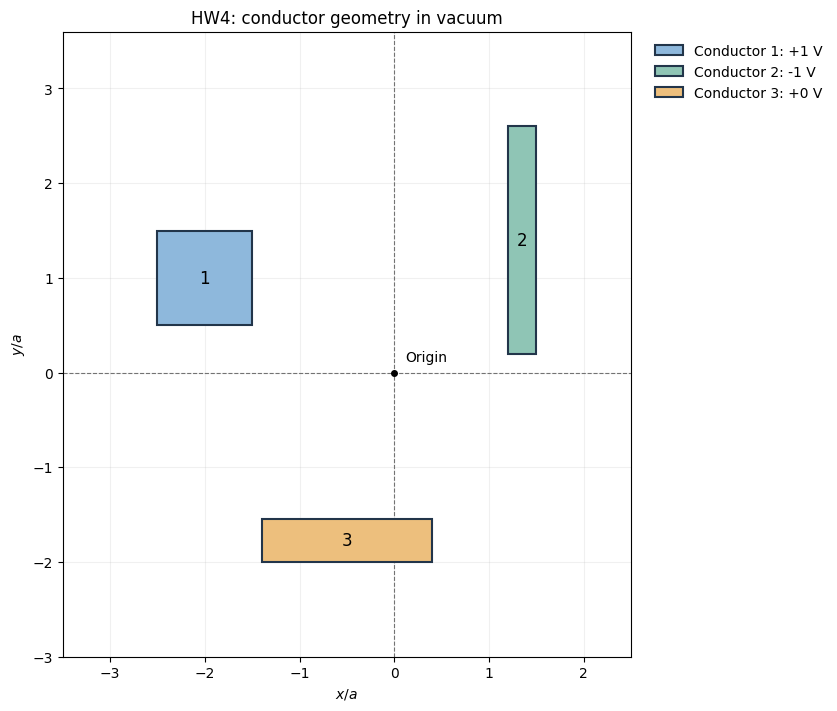

In [4]:
fig, ax = plot_geometry(conductors)
plt.show()


## Step 2 — Finite domain and boundary conditions

Let the computational box be

$$
D=[-L_x,L_x]\times[-L_y,L_y],
\qquad L_x=L_y=20,
$$

in the dimensionless coordinates $X=x/a$ and $Y=y/a$. The initial physical box therefore extends from $-20a$ to $20a$ along each axis.

If $M_i$ denotes the closed region occupied by conductor $i$, define the vacuum region in which the equation is solved as

$$
\Omega=\operatorname{int}(D)\setminus\bigcup_{i=1}^{3}M_i.
$$

The finite-domain problem is

$$
\frac{\partial^2 V}{\partial X^2}
+\frac{\partial^2 V}{\partial Y^2}=0
\quad\text{in }\Omega,
\qquad
V=0\quad\text{on }\partial D,
\qquad
V=V_i\quad\text{throughout }M_i.
$$

The values on the outer boundary and throughout each metal remain fixed during relaxation. Only vacuum points strictly inside the box will be updated.

**Domain size is a numerical parameter.** The choice $L_x=L_y=20$ is an initial value for later domain-convergence tests. A grounded finite boundary does not, by itself, establish compatibility with $V(\infty)=0$ in the two-dimensional exterior problem. Keep the conductor geometry fixed when enlarging the box.

In [5]:
import numpy as np

# Half-width and half-height, both in units of a.
Lx, Ly = 20.0, 20.0
V_outer = 0.0  # volts

domain = dict(
    xmin=-Lx,
    xmax=Lx,
    ymin=-Ly,
    ymax=Ly,
    potential=V_outer,
)

if Lx <= 0 or Ly <= 0:
    raise ValueError("Domain half-widths must be positive.")

# All conductors must lie strictly inside the outer boundary.
for metal in conductors:
    if not (
        domain["xmin"] < metal["xmin"] < metal["xmax"] < domain["xmax"]
        and domain["ymin"] < metal["ymin"] < metal["ymax"] < domain["ymax"]
    ):
        raise ValueError(f"Conductor {metal['number']} must lie inside the box.")


### Encode the fixed and unknown regions

The following function accepts coordinate arrays and returns the boundary data. It will be called with the numerical grid in step 3.

| Returned item | Meaning |
|---|---|
| `inside_domain` | Points inside or on the finite box |
| `outer_boundary` | Points on the four outer edges |
| `conductor_masks` | A mask for each conductor, including its surface |
| `fixed_mask` | All points whose potential must remain prescribed |
| `free_mask` | Vacuum points inside the box, where Laplace's equation will be solved |
| `fixed_values` | Prescribed voltages at fixed points; `NaN` elsewhere |

Here `NaN` marks a potential that is not prescribed. It is not an initial guess for the solver. A separate initial potential array will be introduced later. The coordinate tolerance below only handles floating-point roundoff; it does not depend on mesh spacing.

In [6]:
def make_boundary_data(X, Y, conductors, domain):
    """Classify coordinate arrays and assign Dirichlet values, in volts."""
    X, Y = np.broadcast_arrays(np.asarray(X, dtype=float), np.asarray(Y, dtype=float))

    # Small tolerance for matching coordinates to geometric boundaries.
    coordinate_scale = max(
        1.0,
        abs(domain["xmin"]),
        abs(domain["xmax"]),
        abs(domain["ymin"]),
        abs(domain["ymax"]),
    )
    tol = 16 * np.finfo(float).eps * coordinate_scale

    inside = (
        (X >= domain["xmin"] - tol)
        & (X <= domain["xmax"] + tol)
        & (Y >= domain["ymin"] - tol)
        & (Y <= domain["ymax"] + tol)
    )
    outer = inside & (
        np.isclose(X, domain["xmin"], rtol=0, atol=tol)
        | np.isclose(X, domain["xmax"], rtol=0, atol=tol)
        | np.isclose(Y, domain["ymin"], rtol=0, atol=tol)
        | np.isclose(Y, domain["ymax"], rtol=0, atol=tol)
    )

    fixed_values = np.full(X.shape, np.nan, dtype=float)
    fixed_values[outer] = domain["potential"]
    metal_mask = np.zeros(X.shape, dtype=bool)
    conductor_masks = {}

    for metal in conductors:
        on_metal = inside & (
            (X >= metal["xmin"] - tol)
            & (X <= metal["xmax"] + tol)
            & (Y >= metal["ymin"] - tol)
            & (Y <= metal["ymax"] + tol)
        )
        if np.any(on_metal & (outer | metal_mask)):
            raise ValueError("Fixed regions overlap at the supplied coordinates.")
        conductor_masks[metal["number"]] = on_metal
        metal_mask |= on_metal
        fixed_values[on_metal] = metal["potential"]

    fixed = outer | metal_mask
    free = inside & ~fixed
    return dict(
        inside_domain=inside,
        outer_boundary=outer,
        conductor_masks=conductor_masks,
        fixed_mask=fixed,
        free_mask=free,
        fixed_values=fixed_values,
    )


### Visualize the domain and prescribed potentials

The left panel shows the finite outer boundary at its actual scale. The right panel enlarges the conductor region. Its plot frame is only a viewing window.

The shaded rectangles show the prescribed metal regions; this is a geometry and boundary-condition plot. The vacuum potential remains to be computed.

In [7]:
def plot_domain_and_boundaries(conductors, domain):
    """Show the complete computational box and a close view of the metals."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
    full, zoom = axes

    for ax in axes:
        for metal in conductors:
            width = metal["xmax"] - metal["xmin"]
            height = metal["ymax"] - metal["ymin"]
            ax.add_patch(
                Rectangle(
                    (metal["xmin"], metal["ymin"]),
                    width,
                    height,
                    facecolor=metal["color"],
                    edgecolor="#22354a",
                    linewidth=1.2,
                    zorder=3,
                    label=f"Conductor {metal['number']}: {metal['potential']:+g} V",
                )
            )
            if ax is zoom:
                ax.text(
                    (metal["xmin"] + metal["xmax"]) / 2,
                    (metal["ymin"] + metal["ymax"]) / 2,
                    str(metal["number"]),
                    ha="center",
                    va="center",
                    fontsize=12,
                    zorder=4,
                )
        ax.axhline(0, color="0.6", linestyle="--", linewidth=0.7)
        ax.axvline(0, color="0.6", linestyle="--", linewidth=0.7)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(r"$x/a$")
        ax.set_ylabel(r"$y/a$")

    width = domain["xmax"] - domain["xmin"]
    height = domain["ymax"] - domain["ymin"]
    full.add_patch(
        Rectangle(
            (domain["xmin"], domain["ymin"]),
            width,
            height,
            fill=False,
            edgecolor="#355d91",
            linewidth=2,
            zorder=4,
        )
    )
    pad = 0.08 * max(width, height)
    full.set_xlim(domain["xmin"] - pad, domain["xmax"] + pad)
    full.set_ylim(domain["ymin"] - pad, domain["ymax"] + pad)
    full.set_title(f"Finite domain: outer boundary at {domain['potential']:g} V")
    full.text(
        0.10,
        0.80,
        r"Vacuum: $\nabla^2 V=0$",
        transform=full.transAxes,
        fontsize=11,
    )

    margin = 1.0
    zoom.set_xlim(
        min(m["xmin"] for m in conductors) - margin,
        max(m["xmax"] for m in conductors) + margin,
    )
    zoom.set_ylim(
        min(m["ymin"] for m in conductors) - margin,
        max(m["ymax"] for m in conductors) + margin,
    )
    zoom.set_title("Conductor region (enlarged)")
    zoom.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
    return fig, axes


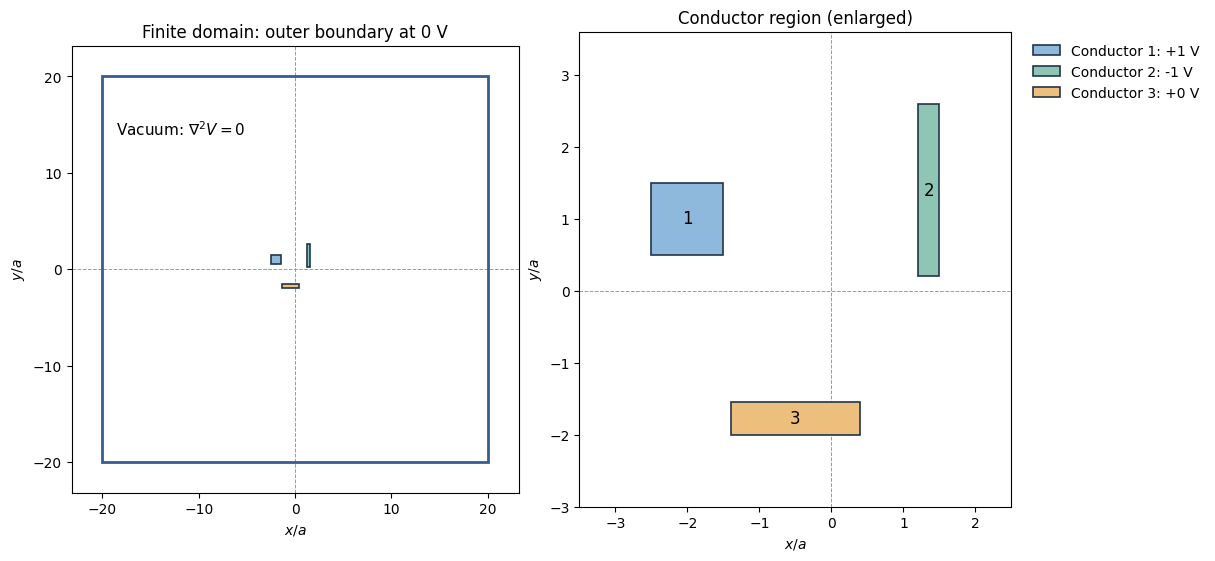

In [8]:
fig, axes = plot_domain_and_boundaries(conductors, domain)
plt.show()


## Step 3 — Numerical mesh and node classification

Use a Cartesian tensor-product mesh: every $x_i$ is combined with every $y_j$. Both axes include the outer endpoints and all rectangular conductor edges.

Two mesh choices are provided:

- **Nonuniform:** intervals in the conductor region and its gaps have spacing at most \`fine_h\`. The fine region extends beyond the conductor bounding box by \`fine_padding\`. Spacings grow geometrically toward the distant outer boundary. Far-region spacings are rescaled slightly to end exactly on the box.
- **Uniform:** the requested \`uniform_h\` must divide the box lengths and place every conductor edge on a grid line. The code rejects an incompatible spacing rather than silently changing the geometry. The initial value $0.05a$ fits the current geometry.

Because the mesh is a tensor product, fine coordinate lines continue across the entire box; this is not a locally adaptive mesh.

\`refinement_levels\` bisects every interval after either base mesh is constructed. This preserves existing nodes and conductor edges for subsequent nested grid-convergence tests. Keep the base parameters fixed when using this refinement option.

The arrays use the convention

$$
X_{j,i}=x_i,\qquad Y_{j,i}=y_j,
$$

so a future potential array will be indexed as \`V[j, i]\` and have shape \`(len(y), len(x))\`.

In [9]:
# Select "nonuniform" or "uniform", then rerun the cells below.
mesh_kind = "nonuniform"

# All spacings and distances are expressed in units of a.
fine_h = 0.05
fine_padding = 1.0
growth_ratio = 1.15
uniform_h = 0.05

# 0: base mesh; 1: bisect all intervals once; 2: bisect twice.
refinement_levels = 0


In [10]:
def uniform_axis(lower, upper, edges, step):
    """Uniform coordinates with conductor edges aligned to grid nodes."""
    if not np.isfinite(step) or step <= 0:
        raise ValueError("Uniform spacing must be positive and finite.")
    cells_float = (upper - lower) / step
    cells = int(round(cells_float))
    if cells < 1 or not np.isclose(cells_float, cells, rtol=0, atol=1e-9):
        raise ValueError("Uniform spacing must divide the domain length.")

    positions = (edges - lower) / step
    indices = np.rint(positions).astype(int)
    if not np.allclose(positions, indices, rtol=0, atol=1e-9):
        raise ValueError(
            "Uniform spacing does not align with every metal edge. "
            "For the current geometry, use 0.05 or a subdivision of it."
        )
    axis = np.linspace(lower, upper, cells + 1)
    # Snap only floating-point roundoff to the exact supplied edge values.
    axis[indices] = edges
    return axis


def geometric_tail(start, end, adjacent_step, ratio):
    """Coordinates growing outward from a fine-region endpoint."""
    distance = abs(end - start)
    if distance == 0:
        return np.array([start], dtype=float)

    first_step = adjacent_step * ratio
    count = max(
        1, int(np.ceil(np.log1p(distance * (ratio - 1) / first_step) / np.log(ratio)))
    )
    widths = first_step * ratio ** np.arange(count)
    widths *= distance / widths.sum()
    direction = 1.0 if end > start else -1.0
    tail = np.r_[start, start + direction * np.cumsum(widths)]
    tail[-1] = end
    return tail


def nonuniform_axis(lower, upper, edges, step, padding, ratio):
    """Fine edge-aligned central region, with stretched outer regions."""
    if not np.isfinite(step) or step <= 0:
        raise ValueError("Fine spacing must be positive and finite.")
    if not np.isfinite(padding) or padding < 0:
        raise ValueError("Fine padding must be nonnegative and finite.")
    if not np.isfinite(ratio) or ratio <= 1:
        raise ValueError("The geometric growth ratio must exceed one.")

    fine_lower = max(lower, edges.min() - padding)
    fine_upper = min(upper, edges.max() + padding)
    anchors = np.unique(np.r_[fine_lower, edges, fine_upper])

    parts = []
    for left, right in zip(anchors[:-1], anchors[1:]):
        count = max(1, int(np.ceil((right - left) / step - 1e-12)))
        parts.append(np.linspace(left, right, count + 1)[:-1])
    center = np.r_[np.concatenate(parts), anchors[-1]]

    left = geometric_tail(center[0], lower, center[1] - center[0], ratio)
    right = geometric_tail(center[-1], upper, center[-1] - center[-2], ratio)
    return np.r_[left[::-1][:-1], center, right[1:]]


def bisect_axis(axis, levels):
    """Nested refinement: retain all old nodes and insert midpoints."""
    if not isinstance(levels, (int, np.integer)) or levels < 0:
        raise ValueError("Refinement levels must be a nonnegative integer.")
    refined = np.asarray(axis, dtype=float).copy()
    for _ in range(levels):
        new_axis = np.empty(2 * len(refined) - 1)
        new_axis[::2] = refined
        new_axis[1::2] = (refined[:-1] + refined[1:]) / 2
        refined = new_axis
    return refined


In [11]:
# Every edge coordinate is an anchor on the corresponding axis.
x_edges = np.unique(
    [value for metal in conductors for value in (metal["xmin"], metal["xmax"])]
)
y_edges = np.unique(
    [value for metal in conductors for value in (metal["ymin"], metal["ymax"])]
)

if mesh_kind == "nonuniform":
    x = nonuniform_axis(
        domain["xmin"],
        domain["xmax"],
        x_edges,
        fine_h,
        fine_padding,
        growth_ratio,
    )
    y = nonuniform_axis(
        domain["ymin"],
        domain["ymax"],
        y_edges,
        fine_h,
        fine_padding,
        growth_ratio,
    )
elif mesh_kind == "uniform":
    x = uniform_axis(domain["xmin"], domain["xmax"], x_edges, uniform_h)
    y = uniform_axis(domain["ymin"], domain["ymax"], y_edges, uniform_h)
else:
    raise ValueError("mesh_kind must be 'nonuniform' or 'uniform'.")

x = bisect_axis(x, refinement_levels)
y = bisect_axis(y, refinement_levels)
dx, dy = np.diff(x), np.diff(y)

if not (np.all(dx > 0) and np.all(dy > 0)):
    raise ValueError("Mesh coordinates must be strictly increasing.")

X, Y = np.meshgrid(x, y, indexing="xy")


### Apply the boundary data

Reuse `make_boundary_data` from step 2. The outer boundary and all metal nodes, including surfaces, are fixed. Only the vacuum nodes inside the box belong to `free_mask`.

The integer array `node_type` identifies each region independently of its voltage:

| Code | Region | Status |
|---|---|---|
| 0 | Vacuum inside the box | Unknown |
| 1 | Outer boundary | Fixed at `V_outer` |
| 2 | Conductor 1 | Fixed at `V1` |
| 3 | Conductor 2 | Fixed at `V2` |
| 4 | Conductor 3 | Fixed at `V3` |

In particular, conductor 3 and the outer boundary remain distinguishable even though both currently have zero potential. `fixed_values` retains `NaN` at unknown nodes; no vacuum potential has been initialized or solved yet.

In [12]:
boundary_data = make_boundary_data(X, Y, conductors, domain)
fixed_mask = boundary_data["fixed_mask"]
free_mask = boundary_data["free_mask"]
fixed_values = boundary_data["fixed_values"]
conductor_masks = boundary_data["conductor_masks"]

node_type = np.full(X.shape, -1, dtype=int)
node_type[free_mask] = 0
node_type[boundary_data["outer_boundary"]] = 1
for metal in conductors:
    node_type[conductor_masks[metal["number"]]] = metal["number"] + 1

if np.any(fixed_mask & free_mask) or not np.all(fixed_mask | free_mask):
    raise ValueError("Every mesh node must be either fixed or unknown.")
if np.any(node_type < 0):
    raise ValueError("Some mesh nodes were not classified.")

# Display mesh diagnostics when this cell is run.
print(f"Mesh: {mesh_kind}; refinement level: {refinement_levels}")
print(f"Nx = {len(x)}, Ny = {len(y)}, total nodes = {X.size:,}")
print(f"dx/a: {dx.min():.5g} to {dx.max():.5g}")
print(f"dy/a: {dy.min():.5g} to {dy.max():.5g}")
print(f"Unknown vacuum nodes: {np.count_nonzero(free_mask):,}")
print(
    f"Fixed outer-boundary nodes: "
    f"{np.count_nonzero(boundary_data['outer_boundary']):,}"
)
for metal in conductors:
    count = np.count_nonzero(conductor_masks[metal["number"]])
    print(f"Fixed conductor {metal['number']} nodes: {count:,}")


Mesh: nonuniform; refinement level: 0
Nx = 177, Ny = 189, total nodes = 33,453
dx/a: 0.05 to 2.3291
dy/a: 0.05 to 2.2626
Unknown vacuum nodes: 31,571
Fixed outer-boundary nodes: 728
Fixed conductor 1 nodes: 441
Fixed conductor 2 nodes: 343
Fixed conductor 3 nodes: 370


### Inspect grid lines and node types

The left panel shows the full mesh and the fixed outer-boundary nodes. The right panel shows the mesh near the conductors, with nodes colored by region. Colored conductor outlines mark the exact metal surfaces.

Switch `mesh_kind` to `"uniform"` and rerun the construction, classification, and plotting cells to inspect the uniform alternative. The full uniform mesh will look dense at this scale; use the enlarged panel to inspect individual nodes.

In [13]:
def plot_mesh_and_nodes(x, y, X, Y, node_type, conductors, domain):
    """Plot the actual mesh and classify nodes in a close view."""
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    full, zoom = axes
    margin = 0.6
    zoom_x = (
        min(m["xmin"] for m in conductors) - margin,
        max(m["xmax"] for m in conductors) + margin,
    )
    zoom_y = (
        min(m["ymin"] for m in conductors) - margin,
        max(m["ymax"] for m in conductors) + margin,
    )

    extent = max(domain["xmax"] - domain["xmin"], domain["ymax"] - domain["ymin"])
    pad = 0.025 * extent
    full.set_xlim(domain["xmin"] - pad, domain["xmax"] + pad)
    full.set_ylim(domain["ymin"] - pad, domain["ymax"] + pad)
    zoom.set_xlim(*zoom_x)
    zoom.set_ylim(*zoom_y)

    colors = {0: "#b0bdc9", 1: "#20252a"}
    labels = {0: "Vacuum: unknown", 1: "Outer boundary: fixed"}
    for metal in conductors:
        key = metal["number"] + 1
        colors[key] = metal["color"]
        labels[key] = f"Metal {metal['number']}: {metal['potential']:+g} V"

    for ax in axes:
        xlo, xhi = ax.get_xlim()
        ylo, yhi = ax.get_ylim()
        ax.vlines(
            x[(x >= xlo) & (x <= xhi)],
            max(ylo, y[0]),
            min(yhi, y[-1]),
            color="0.7",
            linewidth=0.35,
            alpha=0.65,
            zorder=0,
        )
        ax.hlines(
            y[(y >= ylo) & (y <= yhi)],
            max(xlo, x[0]),
            min(xhi, x[-1]),
            color="0.7",
            linewidth=0.35,
            alpha=0.65,
            zorder=0,
        )
        for metal in conductors:
            ax.add_patch(
                Rectangle(
                    (metal["xmin"], metal["ymin"]),
                    metal["xmax"] - metal["xmin"],
                    metal["ymax"] - metal["ymin"],
                    facecolor="none",
                    edgecolor=metal["color"],
                    linewidth=2,
                    zorder=4,
                )
            )
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(r"$x/a$")
        ax.set_ylabel(r"$y/a$")

    outer = node_type == 1
    full.scatter(X[outer], Y[outer], s=3, c=colors[1], zorder=3)
    full.add_patch(
        Rectangle(
            (domain["xmin"], domain["ymin"]),
            domain["xmax"] - domain["xmin"],
            domain["ymax"] - domain["ymin"],
            fill=False,
            edgecolor=colors[1],
            linewidth=1.2,
        )
    )
    full.set_title("Full numerical mesh")

    near = (X >= zoom_x[0]) & (X <= zoom_x[1]) & (Y >= zoom_y[0]) & (Y <= zoom_y[1])
    for key in colors:
        selected = near & (node_type == key)
        zoom.scatter(
            X[selected],
            Y[selected],
            s=7 if key == 0 else 11,
            c=colors[key],
            edgecolors="none",
            zorder=2,
            rasterized=True,
        )
    zoom.set_title("Fixed and unknown nodes near the conductors")
    handles = [
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markerfacecolor=colors[key],
            markeredgecolor="none",
            label=labels[key],
            markersize=6,
        )
        for key in colors
    ]
    zoom.legend(
        handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False
    )
    return fig, axes


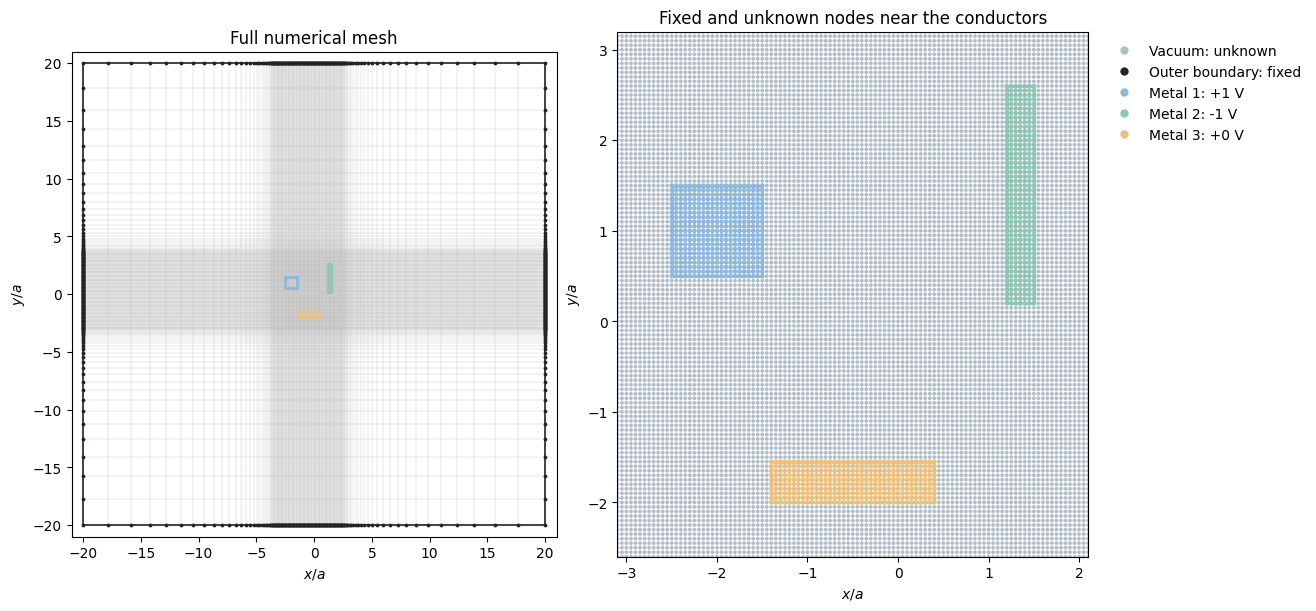

In [14]:
fig, axes = plot_mesh_and_nodes(x, y, X, Y, node_type, conductors, domain)
plt.show()


## Step 4 — Discretize Laplace's equation

In vacuum,

$$
\frac{\partial^2V}{\partial x^2}+
\frac{\partial^2V}{\partial y^2}=0.
$$

The coordinate arrays in the notebook contain $X=x/a$ and $Y=y/a$, so the common factor $a^{-2}$ cancels from Laplace's equation. The formulas below use these dimensionless coordinates.

For an interior node $P=(X_i,Y_j)$, define its four neighbors:

$$
V_P=V_{j,i},\quad
V_E=V_{j,i+1},\quad V_W=V_{j,i-1},\quad
V_N=V_{j+1,i},\quad V_S=V_{j-1,i}.
$$

The four positive spacings are

$$
h_E=X_{i+1}-X_i,\quad h_W=X_i-X_{i-1},\qquad
h_N=Y_{j+1}-Y_j,\quad h_S=Y_j-Y_{j-1}.
$$

### Second derivative with unequal spacings

Approximate the second derivative by the difference of the two neighboring slopes:

$$
\left.\frac{\partial^2 V}{\partial X^2}\right|_P
\approx
\frac{2}{h_E+h_W}
\left[
\frac{V_E-V_P}{h_E}
-
\frac{V_P-V_W}{h_W}
\right].
$$

Likewise,

$$
\left.\frac{\partial^2 V}{\partial Y^2}\right|_P
\approx
\frac{2}{h_N+h_S}
\left[
\frac{V_N-V_P}{h_N}
-
\frac{V_P-V_S}{h_S}
\right].
$$

Collecting terms gives the five-point stencil

$$
(L_hV)_P =
a_E V_E+a_W V_W+a_N V_N+a_S V_S-a_PV_P,
$$

where

$$
a_E=\frac{2}{h_E(h_E+h_W)},\qquad
a_W=\frac{2}{h_W(h_E+h_W)},
$$

$$
a_N=\frac{2}{h_N(h_N+h_S)},\qquad
a_S=\frac{2}{h_S(h_N+h_S)},\qquad
a_P=a_E+a_W+a_N+a_S.
$$

All five named coefficients are positive; the coefficient multiplying $V_P$ in the operator is **$-a_P$**.

The discrete equation is $(L_hV)_P=0$ at each unknown vacuum node. Prescribed neighbor values enter the same formula directly. The equation is not imposed inside a conductor or on the outer boundary.

In [15]:
def build_laplace_stencil(x, y):
    """Coefficients for the interior nodes of a Cartesian nonuniform mesh."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.ndim != 1 or y.ndim != 1 or len(x) < 3 or len(y) < 3:
        raise ValueError("Each axis must be a 1D array with at least 3 nodes.")
    if not (np.all(np.isfinite(x)) and np.all(np.isfinite(y))):
        raise ValueError("Mesh coordinates must be finite.")

    dx = np.diff(x)
    dy = np.diff(y)
    if not (np.all(dx > 0) and np.all(dy > 0)):
        raise ValueError("Mesh coordinates must increase strictly.")

    # At x[i]: west spacing dx[i-1], east spacing dx[i].
    # At y[j]: south spacing dy[j-1], north spacing dy[j].
    h_W = dx[:-1][None, :]  # shape (1, Nx-2)
    h_E = dx[1:][None, :]
    h_S = dy[:-1][:, None]  # shape (Ny-2, 1)
    h_N = dy[1:][:, None]

    interior_shape = (len(y) - 2, len(x) - 2)
    a_E = np.broadcast_to(2.0 / (h_E * (h_E + h_W)), interior_shape)
    a_W = np.broadcast_to(2.0 / (h_W * (h_E + h_W)), interior_shape)
    a_N = np.broadcast_to(2.0 / (h_N * (h_N + h_S)), interior_shape)
    a_S = np.broadcast_to(2.0 / (h_S * (h_N + h_S)), interior_shape)
    a_P = a_E + a_W + a_N + a_S

    return dict(
        a_E=a_E,
        a_W=a_W,
        a_N=a_N,
        a_S=a_S,
        a_P=a_P,
        grid_shape=(len(y), len(x)),
    )


### Coefficient arrays and indexing

The potential will have shape $(N_y,N_x)$, whereas each coefficient array has shape $(N_y-2,N_x-2)$ because the outermost nodes do not require a stencil.

Thus, the coefficients at the full-grid node $V[j,i]$ are stored at index $[j-1,i-1]$. The corresponding active-node mask is \`free_mask[1:-1, 1:-1]\`.

Coefficients can be constructed for every interior array position. Only those selected by the vacuum mask are used as equations.

In [16]:
stencil = build_laplace_stencil(x, y)
free_interior = free_mask[1:-1, 1:-1]

print(f"Full potential-array shape: {stencil['grid_shape']}")
print(f"Coefficient-array shape: {stencil['a_P'].shape}")
print(f"Discrete Laplace equations: {np.count_nonzero(free_interior):,}")


Full potential-array shape: (189, 177)
Coefficient-array shape: (187, 175)
Discrete Laplace equations: 31,571


### Evaluate the discrete equation on a trial potential

For Laplace's equation, the residual is

$$
R_{j,i}=(L_hV)_{j,i}.
$$

It vanishes at every free node for an exact solution of the discrete equations. This condition describes the discrete problem; mesh and domain errors still require separate convergence tests.

The function below accepts a **complete, finite trial potential** including the prescribed metal and outer-boundary values. It returns a full-size array with residuals at free nodes and \`NaN\` at fixed nodes. It does not change the potential.

The function is defined here for use after the initial guess is created in step 5. Do not pass \`fixed_values\` directly: it still contains \`NaN\` at unknown vacuum nodes.

Because the numerical coordinates are $X$ and $Y$, the returned residual is for $(\partial_X^2+\partial_Y^2)V$. The physical Laplacian is this quantity divided by $a^2$.

In [17]:
def laplace_residual(V, stencil, free_mask):
    """Discrete Laplacian on free nodes; NaN on fixed nodes."""
    V = np.asarray(V, dtype=float)
    free_mask = np.asarray(free_mask, dtype=bool)
    if V.shape != stencil["grid_shape"] or free_mask.shape != V.shape:
        raise ValueError("Potential, mask, and stencil shapes must agree.")
    if not np.all(np.isfinite(V)):
        raise ValueError(
            "Supply a finite trial potential at every grid node. "
            "fixed_values alone is not a complete trial potential."
        )
    if (
        np.any(free_mask[0, :])
        or np.any(free_mask[-1, :])
        or np.any(free_mask[:, 0])
        or np.any(free_mask[:, -1])
    ):
        raise ValueError("Outer-boundary nodes must remain fixed.")

    # Full-grid neighbor slices, aligned with each interior center.
    interior_laplacian = (
        stencil["a_E"] * V[1:-1, 2:]
        + stencil["a_W"] * V[1:-1, :-2]
        + stencil["a_N"] * V[2:, 1:-1]
        + stencil["a_S"] * V[:-2, 1:-1]
        - stencil["a_P"] * V[1:-1, 1:-1]
    )

    residual = np.full(V.shape, np.nan, dtype=float)
    residual[1:-1, 1:-1] = np.where(free_mask[1:-1, 1:-1], interior_laplacian, np.nan)
    return residual


### Uniform-grid limit and accuracy

If $h_E=h_W=\Delta X$ and $h_N=h_S=\Delta Y$, the operator becomes

$$
(L_hV)_P=
\frac{V_E-2V_P+V_W}{\Delta X^2}
+\frac{V_N-2V_P+V_S}{\Delta Y^2}.
$$

For a square uniform mesh with $\Delta X=\Delta Y=h$, setting the residual to zero gives

$$
V_P=\frac{V_E+V_W+V_N+V_S}{4}.
$$

On the general mesh, the corresponding relation is the weighted average

$$
V_P=\frac{a_EV_E+a_WV_W+a_NV_N+a_SV_S}{a_P}.
$$

Step 5 will specify how this relation is used during iteration.

**Accuracy on unequal spacings.** For a smooth potential, Taylor expansion of the $X$ stencil gives

$$
D_{XX}V
=
V_{XX}
+\frac{h_E-h_W}{3}V_{XXX}
+O(h_E^2+h_W^2).
$$

Therefore, second-order local accuracy requires additional control of the spacing variation; arbitrary unequal spacings do not automatically give a second-order stencil. Uniform spacings cancel the displayed third-derivative term. Smooth mesh families with $h_E-h_W=O(h^2)$ also do so to second order. The observed solution accuracy, especially near metal corners, will be assessed by later mesh-convergence tests.

## Step 5 — Initial guess and fictitious-time relaxation

Initialize the unknown vacuum nodes with

$$
V^{(0)}_{j,i}=0,
$$

then assign the prescribed values at all fixed nodes:

$$
V^{(0)}=V_i\ \text{in conductor }i,\qquad
V^{(0)}=V_{\mathrm{outer}}=0\ \text{on the outer boundary}.
$$

The initial array need not satisfy Laplace's equation. It must be finite everywhere and satisfy the fixed-potential conditions. \`V_initial\` is retained separately so subsequent runs can start from the same guess.

In [18]:
def initialize_potential(boundary_data, vacuum_value=0.0):
    """Create a finite initial guess and impose all prescribed voltages."""
    fixed = np.asarray(boundary_data["fixed_mask"], dtype=bool)
    free = np.asarray(boundary_data["free_mask"], dtype=bool)
    values = np.asarray(boundary_data["fixed_values"], dtype=float)

    if free.shape != fixed.shape or values.shape != fixed.shape:
        raise ValueError("Boundary arrays must have the same shape.")
    if np.any(fixed & free) or not np.all(fixed | free):
        raise ValueError("Fixed and free masks must partition the whole grid.")
    if not np.isfinite(vacuum_value):
        raise ValueError("The initial vacuum potential must be finite.")
    if not np.all(np.isfinite(values[fixed])):
        raise ValueError("Every fixed node must have a finite prescribed value.")

    V = np.full(fixed.shape, vacuum_value, dtype=float)
    V[fixed] = values[fixed]
    return V


In [19]:
initial_vacuum_potential = 0.0  # volts
V_initial = initialize_potential(boundary_data, vacuum_value=initial_vacuum_potential)

print(f"Initial array shape: {V_initial.shape}")
print(f"Initial vacuum potential: {initial_vacuum_potential:g} V")
print("Metal and outer-boundary nodes have their prescribed values.")


Initial array shape: (189, 177)
Initial vacuum potential: 0 V
Metal and outer-boundary nodes have their prescribed values.


### Connection to the lecture slide

The lecture introduces a fictitious time for the Poisson problem. In this homework, the equation is solved only in the charge-free vacuum, where $\rho=0$. With no dependence on the third coordinate, the evolution equation therefore reduces to the two-dimensional diffusion equation written below. The induced conductor surface charges are represented implicitly by the fixed-potential boundary conditions.

The slide also identifies successive over-relaxation (SOR) as an optional acceleration. The present implementation follows the explicit fictitious-time update; SOR would require its own update rule and relaxation parameter if added later.

### Introduce the artificial time

With the diffusion coefficient absorbed into the definition of artificial time, use

$$
\frac{\partial V}{\partial\tau}
=
\frac{\partial^2V}{\partial X^2}
+\frac{\partial^2V}{\partial Y^2},
\qquad X=x/a,\quad Y=y/a.
$$

Here $\tau$ is a numerical relaxation parameter. The stationary state satisfies Laplace's equation.

Forward Euler gives, at each free node,

$$
V_P^{(n+1)}
=
V_P^{(n)}+\Delta\tau\,(L_hV^{(n)})_P.
$$

Using the stencil from step 4,

$$
V_P^{(n+1)}
=
(1-\Delta\tau\,a_P)V_P^{(n)}
+\Delta\tau
\left(
a_EV_E^{(n)}+a_WV_W^{(n)}
+a_NV_N^{(n)}+a_SV_S^{(n)}
\right).
$$

Every term on the right is evaluated using the **previous array**. A separate array holds the updated potential.

At fixed nodes, enforce $V^{(n+1)}=V_{\mathrm{prescribed}}$ during every step.

### Choose a stable global time step

All neighbor coefficients are positive. A sufficient stability and monotonicity condition is

$$
0<\Delta\tau\leq
\Delta\tau_{\max}
\equiv\frac{1}{\max_{P\in\mathrm{free}}a_P}.
$$

Under this condition, the weights in the update are nonnegative and sum to one, so the update cannot create a value outside the range of its old center and neighboring values. This is a sufficient bound, not a claim about the sharp spectral stability limit.

Choose a safety factor $s=0.9$:

$$
\Delta\tau=s\,\Delta\tau_{\max}.
$$

For a square uniform mesh, $a_P=4/h^2$, recovering $\Delta\tau_{\max}=h^2/4$.

One global $\Delta\tau$ is used throughout the domain. The finest spacings constrain it, so relaxation across a large box may require many iterations. Recompute the limit whenever the mesh or the free-node mask changes.

In [20]:
def explicit_time_step_limit(stencil, free_mask):
    """Sufficient forward-Euler bound for the active Laplace equations."""
    free = np.asarray(free_mask, dtype=bool)
    if free.shape != stencil["grid_shape"]:
        raise ValueError("The free mask must match the stencil grid shape.")
    if (
        np.any(free[0, :])
        or np.any(free[-1, :])
        or np.any(free[:, 0])
        or np.any(free[:, -1])
    ):
        raise ValueError("Outer-boundary nodes must be fixed.")

    active = free[1:-1, 1:-1]
    if not np.any(active):
        raise ValueError("There must be at least one unknown vacuum node.")
    diagonal = stencil["a_P"][active]
    if not np.all(np.isfinite(diagonal)) or np.any(diagonal <= 0):
        raise ValueError("Active diagonal coefficients must be positive and finite.")
    return 1.0 / float(np.max(diagonal))


In [21]:
time_step_safety = 0.9
if not (0 < time_step_safety < 1):
    raise ValueError("Choose a time-step safety factor strictly between 0 and 1.")

dtau_max = explicit_time_step_limit(stencil, free_mask)
dtau = time_step_safety * dtau_max

print(f"Sufficient time-step limit: {dtau_max:.8g}")
print(f"Selected global time step: {dtau:.8g}")
print("Artificial time is defined using the scaled coordinates X and Y.")


Sufficient time-step limit: 0.000625
Selected global time step: 0.0005625
Artificial time is defined using the scaled coordinates X and Y.


In [22]:
def fictitious_time_step(V, stencil, boundary_data, dtau):
    """One simultaneous forward-Euler update; preserve all Dirichlet data."""
    fixed = np.asarray(boundary_data["fixed_mask"], dtype=bool)
    free = np.asarray(boundary_data["free_mask"], dtype=bool)
    values = np.asarray(boundary_data["fixed_values"], dtype=float)
    V_old = np.array(V, dtype=float, copy=True)

    if (
        V_old.shape != stencil["grid_shape"]
        or fixed.shape != V_old.shape
        or free.shape != V_old.shape
        or values.shape != V_old.shape
    ):
        raise ValueError("Potential, boundary arrays, and stencil must agree.")
    if np.any(fixed & free) or not np.all(fixed | free):
        raise ValueError("Every grid node must be either fixed or free.")
    if not np.all(np.isfinite(values[fixed])):
        raise ValueError("Fixed nodes require finite prescribed voltages.")

    dtau_limit = explicit_time_step_limit(stencil, free)
    if not np.isfinite(dtau) or not (0 < dtau <= dtau_limit):
        raise ValueError(f"dtau must be positive and no greater than {dtau_limit:.8g}.")

    # Enforce the boundary data before using any neighbor values.
    V_old[fixed] = values[fixed]
    residual_old = laplace_residual(V_old, stencil, free)

    # All residuals came from V_old; no updated neighbor is used here.
    V_new = V_old.copy()
    V_new[free] = V_old[free] + dtau * residual_old[free]

    # Explicitly reapply the prescribed values after the update.
    V_new[fixed] = values[fixed]
    if not np.all(np.isfinite(V_new)):
        raise FloatingPointError("The updated potential contains nonfinite values.")
    return V_new


### Optional short preview when the notebook is run

The next cell starts from \`V_initial\` and performs 50 explicit steps. It records the artificial time, the maximum residual over free nodes, and the maximum change in the vacuum potential.

This finite-step preview demonstrates the update; it does **not** declare convergence. Step 6 will define the stopping criteria and validation checks. The arrays \`V_initial\` and \`V_preview\` are independent, and rerunning this cell restarts from the same initial guess.

In [23]:
n_preview_steps = 50
if not isinstance(n_preview_steps, (int, np.integer)) or n_preview_steps < 1:
    raise ValueError("n_preview_steps must be a positive integer.")

V_preview = V_initial.copy()
initial_residual = laplace_residual(V_preview, stencil, free_mask)
preview_history = {
    "iteration": [0],
    "tau": [0.0],
    "residual_inf": [float(np.max(np.abs(initial_residual[free_mask])))],
    "change_inf": [np.nan],  # No update has occurred at iteration zero.
}

for iteration in range(1, n_preview_steps + 1):
    V_next = fictitious_time_step(V_preview, stencil, boundary_data, dtau)
    max_change = float(np.max(np.abs(V_next[free_mask] - V_preview[free_mask])))
    V_preview = V_next
    residual = laplace_residual(V_preview, stencil, free_mask)

    preview_history["iteration"].append(iteration)
    preview_history["tau"].append(iteration * dtau)
    preview_history["residual_inf"].append(float(np.max(np.abs(residual[free_mask]))))
    preview_history["change_inf"].append(max_change)

print(f"Preview completed: {n_preview_steps} explicit steps.")
print(f"Final preview residual: {preview_history['residual_inf'][-1]:.6g}")
print(f"Last maximum potential change: {preview_history['change_inf'][-1]:.6g} V")
print("Convergence has not been assessed; stopping criteria come in step 6.")


Preview completed: 50 explicit steps.
Final preview residual: 8.4313
Last maximum potential change: 0.00483306 V
Convergence has not been assessed; stopping criteria come in step 6.


## Step 6 — Stopping criteria and validation

Let $V_{\mathrm{ref}}=\max_{\mathrm{fixed}}|V_{\mathrm{prescribed}}|$, using $1\,\mathrm{V}$ only if all prescribed values are zero. Keep this reference fixed across comparisons.

Monitor the residual and the actual change between successive iterations:

$$
r_n=\frac{\max_{\mathrm{free}}|(L_hV^{(n)})_{j,i}|}{V_{\mathrm{ref}}},
\qquad
d_n=\frac{\max_{\mathrm{free}}|V^{(n)}_{j,i}-V^{(n-1)}_{j,i}|}{V_{\mathrm{ref}}}.
$$

The residual uses the dimensionless coordinates $X=x/a$ and $Y=y/a$, with the same reference length $a$ in every study. It is not divided by the initial residual or by mesh-dependent stencil coefficients.

Stop successfully only when **both** $r_n\leq\epsilon_{\mathrm{res}}$ and $d_n\leq\epsilon_{\Delta V}$. The iteration cap returns an explicit failure status if these conditions are not met. A small change alone is insufficient: forward Euler gives $\Delta V=\Delta\tau L_hV$, so reducing the time step also reduces the change.

Residuals and changes are checked every `check_every` iterations and at the final iteration. The recorded change is between two successive iterations, not between two saved records. Fixed-potential error and the discrete maximum principle are also reported.

### A bound on the remaining iterative error

For this positive-coefficient stencil, an additional useful bound is

$$
\|V^{(n)}-V_h^\star\|_\infty
\leq
\frac{\min(\ell_X^2,\ell_Y^2)}{8}
\,\|L_hV^{(n)}\|_\infty,
$$

where $V_h^\star$ is the exact solution of the **discrete finite-box problem**, and $\ell_X,\ell_Y$ are the box widths in units of $a$. The bound assumes exact prescribed values, as enforced here.

It follows from the discrete maximum principle using the nonnegative quadratic barriers $(X-X_{\min})(X_{\max}-X)/2$ and its $Y$ counterpart; the stencil differentiates these quadratics exactly. This bounds iteration error, not mesh or domain error. The code reports the bound in volts so it can be compared with differences between successive numerical solutions.

In [24]:
def solve_laplace_explicit(
    x_axis,
    y_axis,
    bc,
    V_start=None,
    safety=0.9,
    residual_tol=1e-8,
    change_tol=1e-10,
    max_iterations=1_000_000,
    check_every=100,
    report_every=50_000,
    voltage_scale=None,
):
    """Forward Euler with residual/change stopping criteria and honest status."""
    from time import perf_counter

    x_axis = np.asarray(x_axis, dtype=float)
    y_axis = np.asarray(y_axis, dtype=float)
    coefficients = build_laplace_stencil(x_axis, y_axis)
    free = np.asarray(bc["free_mask"], dtype=bool)
    fixed = np.asarray(bc["fixed_mask"], dtype=bool)
    prescribed = np.asarray(bc["fixed_values"], dtype=float)
    # Reuse step 5's checks for the complete partition and fixed values.
    initial = initialize_potential(bc)
    if initial.shape != coefficients["grid_shape"]:
        raise ValueError("Boundary data must match the coordinate axes.")
    if not (np.isfinite(safety) and 0 < safety < 1):
        raise ValueError("safety must lie strictly between 0 and 1.")
    if not all(np.isfinite(t) and t > 0 for t in (residual_tol, change_tol)):
        raise ValueError("Stopping tolerances must be positive and finite.")
    if not isinstance(max_iterations, (int, np.integer)) or max_iterations < 1:
        raise ValueError("max_iterations must be a positive integer.")
    if not isinstance(check_every, (int, np.integer)) or check_every < 1:
        raise ValueError("check_every must be a positive integer.")
    if not isinstance(report_every, (int, np.integer)) or report_every < 0:
        raise ValueError("report_every must be a nonnegative integer.")

    if voltage_scale is None:
        voltage_scale = float(np.max(np.abs(prescribed[fixed])))
        if voltage_scale == 0:
            voltage_scale = 1.0
    if not np.isfinite(voltage_scale) or voltage_scale <= 0:
        raise ValueError("voltage_scale must be positive and finite.")

    V = initial if V_start is None else np.array(V_start, dtype=float, copy=True)
    if V.shape != initial.shape or not np.all(np.isfinite(V)):
        raise ValueError("The starting potential must be finite and match the mesh.")
    V[fixed] = prescribed[fixed]
    V_next = V.copy()
    active = free[1:-1, 1:-1]
    step = safety * explicit_time_step_limit(coefficients, free)
    width_x, width_y = x_axis[-1] - x_axis[0], y_axis[-1] - y_axis[0]
    error_factor = min(width_x**2, width_y**2) / 8.0

    # Cache stencil references; all coefficients remain those of step 4.
    aE, aW = coefficients["a_E"], coefficients["a_W"]
    aN, aS = coefficients["a_N"], coefficients["a_S"]
    aP = coefficients["a_P"]

    def interior_residual(field):
        return (
            aE * field[1:-1, 2:]
            + aW * field[1:-1, :-2]
            + aN * field[2:, 1:-1]
            + aS * field[:-2, 1:-1]
            - aP * field[1:-1, 1:-1]
        )

    residual = interior_residual(V)
    residual_inf = float(np.max(np.abs(residual[active])))
    if not np.isfinite(residual_inf):
        raise FloatingPointError("Initial residual is not finite.")
    r = residual_inf / voltage_scale
    history = dict(iteration=[0], tau=[0.0], residual=[r], change=[np.nan])
    converged = r <= residual_tol
    change = 0.0 if converged else np.nan
    iterations = 0
    started = perf_counter()

    if not converged:
        for iterations in range(1, max_iterations + 1):
            old_center = V[1:-1, 1:-1]
            new_center = V_next[1:-1, 1:-1]
            # Simultaneous Euler update from the old array and old residual.
            new_center[active] = old_center[active] + step * residual[active]
            V_next[fixed] = prescribed[fixed]
            checking = iterations % check_every == 0 or iterations == max_iterations
            if checking:
                change = (
                    float(np.max(np.abs(new_center[active] - old_center[active])))
                    / voltage_scale
                )

            V, V_next = V_next, V
            residual = interior_residual(V)
            if checking:
                residual_inf = float(np.max(np.abs(residual[active])))
                r = residual_inf / voltage_scale
                if not (np.isfinite(r) and np.isfinite(change)):
                    raise FloatingPointError("Nonfinite potential or residual.")
                history["iteration"].append(iterations)
                history["tau"].append(iterations * step)
                history["residual"].append(r)
                history["change"].append(change)
                converged = r <= residual_tol and change <= change_tol
                if report_every and (
                    iterations % report_every == 0
                    or converged
                    or iterations == max_iterations
                ):
                    print(f"n={iterations:,}: residual={r:.3e}, change={change:.3e}")
                if converged:
                    break

    # Use the independently defined step 4 residual for the final report.
    final_residual = laplace_residual(V, coefficients, free)
    residual_inf = float(np.max(np.abs(final_residual[free])))
    r = residual_inf / voltage_scale
    converged = bool(converged and r <= residual_tol)
    fixed_error = float(np.max(np.abs(V[fixed] - prescribed[fixed])))
    boundary_min = float(np.min(prescribed[fixed]))
    boundary_max = float(np.max(prescribed[fixed]))
    maximum_principle_violation = max(
        0.0, boundary_min - float(V.min()), float(V.max()) - boundary_max
    )
    return dict(
        x=x_axis.copy(),
        y=y_axis.copy(),
        V=V,
        boundary_data=bc,
        converged=converged,
        status="converged" if converged else "iteration cap reached",
        iterations=iterations,
        tau=iterations * step,
        dtau=step,
        residual=r,
        change=change,
        residual_tol=residual_tol,
        change_tol=change_tol,
        iteration_error_bound_V=error_factor * residual_inf,
        fixed_error_V=fixed_error,
        maximum_principle_violation_V=maximum_principle_violation,
        voltage_scale=voltage_scale,
        seconds=perf_counter() - started,
        history={k: np.asarray(v) for k, v in history.items()},
    )


In [25]:
def display_results(rows):
    """Readable notebook table without requiring pandas."""
    from html import escape
    from IPython.display import HTML, display

    if not rows:
        print("No results.")
        return
    columns = list(dict.fromkeys(k for row in rows for k in row))

    def format_value(value):
        if isinstance(value, (float, np.floating)):
            return "—" if not np.isfinite(value) else f"{value:.5g}"
        return str(value)

    header = "".join(f"<th>{escape(str(k))}</th>" for k in columns)
    body = "".join(
        "<tr>"
        + "".join(f"<td>{escape(format_value(row.get(k, '')))}</td>" for k in columns)
        + "</tr>"
        for row in rows
    )
    display(
        HTML(
            "<div style='overflow-x:auto'><table><thead><tr>"
            + header
            + "</tr></thead><tbody>"
            + body
            + "</tbody></table></div>"
        )
    )


def result_row(label, result):
    return {
        "Run": label,
        "Status": result["status"],
        "Nx": len(result["x"]),
        "Ny": len(result["y"]),
        "Iterations": result["iterations"],
        "Residual": result["residual"],
        "Last change": result["change"],
        "Iteration error bound (V)": result["iteration_error_bound_V"],
        "Fixed error (V)": result["fixed_error_V"],
        "Range violation (V)": result["maximum_principle_violation_V"],
    }


def plot_iteration_history(result, title="Iteration diagnostics"):
    history = result["history"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
    for ax, key, threshold, ylabel in zip(
        axes,
        ("residual", "change"),
        (result["residual_tol"], result["change_tol"]),
        ("Scaled Laplace residual", "Scaled change per iteration"),
    ):
        values = history[key]
        keep = np.isfinite(values) & (values > 0)
        ax.semilogy(history["iteration"][keep], values[keep], linewidth=1.5)
        ax.axhline(threshold, color="black", linestyle="--", label="Tolerance")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
        ax.legend()
    fig.suptitle(f"{title} — {result['status']}")
    return fig, axes


### Validate against known solutions

Use an independent rectangular box $0\leq X,Y\leq1$ with no internal metals. Prescribe the exact potential on all four edges and initialize the interior to zero.

1. An affine potential $V=0.3+0.4X-0.2Y$ checks the solver, signs, indexing, and boundary preservation on an unequal-spacing mesh. The finite differences represent this solution exactly up to roundoff, so the remaining solution error should be controlled by the stopping tolerance.
2. A nontrivial harmonic potential,

$$
V_{\mathrm{exact}}(X,Y)=
\sin(\pi X)\frac{\sinh(\pi Y)}{\sinh(\pi)},
$$

checks spatial accuracy on both uniform and smoothly stretched meshes. It is zero on three sides and equals $\sin(\pi X)$ on the top side.

Report the maximum actual error, residual, boundary error, and observed order between the two mesh sizes. Only converged runs contribute to the order estimate. The maximum principle compares the solution with the actual prescribed boundary extrema, including for this benchmark.

These cells contain tests for you to execute; no validation outcomes are prefilled.

In [26]:
def make_analytic_box(n, kind, exact_function):
    t = np.linspace(0.0, 1.0, n)
    if kind == "uniform":
        xa, ya = t.copy(), t.copy()
    elif kind == "nonuniform":
        xa = np.expm1(1.2 * t) / np.expm1(1.2)
        ya = np.expm1(0.8 * t) / np.expm1(0.8)
    else:
        raise ValueError("Unknown validation mesh.")
    XA, YA = np.meshgrid(xa, ya, indexing="xy")
    exact = exact_function(XA, YA)
    outer = np.zeros(exact.shape, dtype=bool)
    outer[[0, -1], :] = True
    outer[:, [0, -1]] = True
    values = np.full(exact.shape, np.nan)
    values[outer] = exact[outer]
    bc = dict(
        fixed_mask=outer,
        free_mask=~outer,
        fixed_values=values,
        outer_boundary=outer,
        conductor_masks={},
        inside_domain=np.ones(exact.shape, dtype=bool),
    )
    return xa, ya, bc, exact


def run_analytic_validation(sizes=(17, 33)):
    rows, runs = [], {}
    functions = {
        "affine": lambda X, Y: 0.3 + 0.4 * X - 0.2 * Y,
        "harmonic": lambda X, Y: (
            np.sin(np.pi * X) * np.sinh(np.pi * Y) / np.sinh(np.pi)
        ),
    }
    cases = [("affine", "nonuniform", sizes[0])]
    cases += [
        ("harmonic", kind, n) for kind in ("uniform", "nonuniform") for n in sizes
    ]
    previous = {}
    for name, kind, n in cases:
        xa, ya, bc, exact = make_analytic_box(n, kind, functions[name])
        result = solve_laplace_explicit(
            xa,
            ya,
            bc,
            residual_tol=1e-9,
            change_tol=1e-11,
            max_iterations=200_000,
            check_every=50,
            report_every=0,
        )
        error = float(np.max(np.abs(result["V"] - exact)))
        hmax = max(float(np.diff(xa).max()), float(np.diff(ya).max()))
        order = np.nan
        key = (name, kind)
        if key in previous:
            old_h, old_error, old_converged = previous[key]
            if result["converged"] and old_converged and error > 0 and old_error > 0:
                order = np.log(old_error / error) / np.log(old_h / hmax)
        row = result_row(f"{name}, {kind}, n={n}", result)
        row.update({"Actual max error (V)": error, "Observed order": order})
        if name == "affine":
            check_passed = (
                result["converged"]
                and error <= result["iteration_error_bound_V"] + 1e-11
                and result["fixed_error_V"] <= 1e-12
            )
            row["Affine check"] = "pass" if check_passed else "unresolved or failed"
        rows.append(row)
        previous[key] = (hmax, error, result["converged"])
        runs[(name, kind, n)] = result
    return rows, runs


validation_rows, validation_runs = run_analytic_validation()
display_results(validation_rows)


Run,Status,Nx,Ny,Iterations,Residual,Last change,Iteration error bound (V),Fixed error (V),Range violation (V),Actual max error (V),Observed order,Affine check
"affine, nonuniform, n=17",converged,17,17,3650,9.2159e-10,3.0539e-13,8.0639e-11,0,0,3.2829e-11,—,pass
"harmonic, uniform, n=17",converged,17,17,1300,8.8409e-10,7.9076e-13,1.1051e-10,0,0,0.0011088,—,
"harmonic, uniform, n=33",converged,33,33,5200,9.7543e-10,2.1524e-13,1.2193e-10,0,0,0.00027796,1.9961,
"harmonic, nonuniform, n=17",converged,17,17,3500,8.4371e-10,2.7956e-13,1.0528e-10,0,0,0.0025024,—,
"harmonic, nonuniform, n=33",converged,33,33,14850,9.6784e-10,7.4733e-14,1.2082e-10,0,0,0.00063222,2.0394,


## Step 7 — Separate convergence studies

| Study | Change | Keep fixed | Compare |
|---|---|---|---|
| Iterative | Tighten residual/change tolerances | Mesh, box, potentials, time-step factor | Potential at identical nodes |
| Grid | Bisect every grid interval | Box, metal geometry, tight solver tolerances | Potentials at common base-grid nodes |
| Domain | Append outer grid lines | All existing grid nodes, metal geometry, tight solver tolerances | Potential in a fixed region around the conductors |
| Time step | Change the stable safety factor | Mesh, box, initial guess, solver tolerances | Final potential at identical nodes |

The domain study extends the mesh outward rather than rebuilding its existing tail, so the near-conductor grid is preserved exactly. Comparisons near the conductors use a fixed sampling region and fixed physical points.

A successful stopping flag establishes iterative convergence for that numerical problem. Mesh and domain conclusions require small differences between separately converged solutions. Runs reaching the cap are shown in the tables, but their comparison differences are left undefined.

Explicit diffusion may need many iterations, particularly on refined meshes and larger boxes. Each study has a separate execution cell. Increase the cap or tighten tolerances when the tables indicate insufficient iterative accuracy. No study below assumes that the example voltages ensure neutrality or that finite-box convergence proves the exterior condition at infinity.

In [27]:
# Shared inputs: the current mesh and physical geometry remain the reference.
base_x, base_y = x.copy(), y.copy()
study_conductors = [dict(metal) for metal in conductors]
study_outer_potential = domain["potential"]
study_voltage_scale = float(np.max(np.abs(fixed_values[fixed_mask])))
if study_voltage_scale == 0:
    study_voltage_scale = 1.0

study_max_iterations = 2_000_000  # per solve; reaching it is NOT convergence
study_check_every = 100
study_report_every = 100_000

iterative_tolerances = (1e-4, 1e-6, 1e-8)
mesh_refinements = (0, 1, 2)
domain_scales = (1.0, 1.5, 2.0)
time_step_factors = (0.45, 0.9)
if (
    not iterative_tolerances
    or any(t <= 0 for t in iterative_tolerances)
    or any(b >= a for a, b in zip(iterative_tolerances[:-1], iterative_tolerances[1:]))
):
    raise ValueError("Iterative tolerances must be positive and decrease strictly.")
if (
    not mesh_refinements
    or mesh_refinements[0] != 0
    or any(not isinstance(k, (int, np.integer)) or k < 0 for k in mesh_refinements)
    or any(b <= a for a, b in zip(mesh_refinements[:-1], mesh_refinements[1:]))
):
    raise ValueError("Refinement levels must be increasing integers starting at zero.")

comparison_target_V = 1e-3  # chosen accuracy target for field differences
iteration_budget_fraction = 0.1
near_padding = 1.0

base_X, base_Y = np.meshgrid(base_x, base_y, indexing="xy")
base_free = boundary_data["free_mask"].copy()
near_region = base_free & (
    (base_X >= min(m["xmin"] for m in study_conductors) - near_padding)
    & (base_X <= max(m["xmax"] for m in study_conductors) + near_padding)
    & (base_Y >= min(m["ymin"] for m in study_conductors) - near_padding)
    & (base_Y <= max(m["ymax"] for m in study_conductors) + near_padding)
)
if not np.any(near_region):
    raise ValueError("The comparison region contains no vacuum nodes.")

# Choose nearby BASE-grid nodes, then retain their exact physical coordinates.
probe_targets = {"P0": (0.0, 0.0), "P1": (-0.5, 0.5), "P2": (0.7, -0.8)}
probe_indices = {}
probe_rows = []
for name, (xp, yp) in probe_targets.items():
    i, j = int(np.argmin(abs(base_x - xp))), int(np.argmin(abs(base_y - yp)))
    if not base_free[j, i]:
        raise ValueError(f"Probe {name} is not in the vacuum; choose another target.")
    probe_indices[name] = (j, i)
    probe_rows.append({"Probe": name, "x/a": base_x[i], "y/a": base_y[j]})
display_results(probe_rows)


Probe,x/a,y/a
P0,0,0
P1,-0.5,0.5
P2,0.7,-0.8


In [28]:
def boundary_data_on_axes(xa, ya):
    box = dict(
        xmin=float(xa[0]),
        xmax=float(xa[-1]),
        ymin=float(ya[0]),
        ymax=float(ya[-1]),
        potential=study_outer_potential,
    )
    for metal in study_conductors:
        if not (
            box["xmin"] < metal["xmin"] < metal["xmax"] < box["xmax"]
            and box["ymin"] < metal["ymin"] < metal["ymax"] < box["ymax"]
        ):
            raise ValueError("Every conductor must remain inside the box.")
    XX, YY = np.meshgrid(xa, ya, indexing="xy")
    return make_boundary_data(XX, YY, study_conductors, box)


def common_indices(axis, reference):
    indices = np.searchsorted(axis, reference)
    if np.any(indices >= len(axis)) or not np.allclose(
        axis[indices], reference, rtol=0, atol=1e-11
    ):
        raise ValueError("The new mesh must contain all base-grid coordinates.")
    return indices


def on_base_grid(result):
    ix = common_indices(result["x"], base_x)
    iy = common_indices(result["y"], base_y)
    return result["V"][np.ix_(iy, ix)]


def interpolated_start(result, xa, ya):
    """Interpolate only the initial guess; comparisons use exact shared nodes."""
    intermediate = np.array(
        [
            np.interp(
                xa,
                result["x"],
                row,
                left=study_outer_potential,
                right=study_outer_potential,
            )
            for row in result["V"]
        ]
    )
    return np.array(
        [
            np.interp(
                ya,
                result["y"],
                intermediate[:, i],
                left=study_outer_potential,
                right=study_outer_potential,
            )
            for i in range(len(xa))
        ]
    ).T


def run_study_case(xa, ya, tolerance, start=None, safety=0.9):
    bc = boundary_data_on_axes(xa, ya)
    return solve_laplace_explicit(
        xa,
        ya,
        bc,
        V_start=start,
        safety=safety,
        residual_tol=tolerance,
        change_tol=0.01 * tolerance,
        max_iterations=study_max_iterations,
        check_every=study_check_every,
        report_every=study_report_every,
        voltage_scale=study_voltage_scale,
    )


def add_probe_values(row, result):
    values = on_base_grid(result)
    for name, (j, i) in probe_indices.items():
        row[f"{name} (V)"] = float(values[j, i]) if result["converged"] else np.nan


def pair_difference(previous, current, mask):
    if not (previous["converged"] and current["converged"]):
        return np.nan
    return float(np.max(np.abs((on_base_grid(current) - on_base_grid(previous))[mask])))


def pair_assessment(previous, current, difference):
    if not (previous["converged"] and current["converged"]):
        return "Unresolved: solver did not converge"
    error_budget = (
        previous["iteration_error_bound_V"] + current["iteration_error_bound_V"]
    )
    if error_budget > iteration_budget_fraction * comparison_target_V:
        return "Tighten solver tolerances"
    if difference <= comparison_target_V:
        return "Pair meets chosen target"
    return "Difference exceeds target"


def extend_axis_preserving_nodes(axis, lower, upper, ratio=1.15):
    """Append exterior coordinates, preserving every existing mesh node."""
    axis = np.asarray(axis, dtype=float)
    if lower > axis[0] or upper < axis[-1] or ratio <= 1:
        raise ValueError("New bounds must enclose the old axis; ratio must exceed 1.")
    left = geometric_tail(axis[0], lower, axis[1] - axis[0], ratio)
    right = geometric_tail(axis[-1], upper, axis[-1] - axis[-2], ratio)
    return np.r_[left[::-1][:-1], axis, right[1:]]


### 7.1 Iterative convergence

Tighten the tolerances while holding the mesh, domain, potentials, and time-step factor fixed. Each tighter run starts from the preceding result to avoid repeating the initial diffusion. The table distinguishes additional iterations from cumulative iterations; these warm-start iteration counts should not be compared as independent zero-start timings.

Compare the potentials on all common vacuum nodes. The last run supplies the tight reference for the following studies. If it hits the cap, increase the cap and rerun this cell before interpreting further comparisons.

Iterative study: residual tolerance 0.0001
n=100,000: residual=9.315e-04, change=5.240e-07
n=200,000: residual=1.687e-04, change=9.488e-08
n=232,100: residual=9.998e-05, change=5.624e-08
Iterative study: residual tolerance 1e-06
n=100,000: residual=2.066e-05, change=1.162e-08
n=200,000: residual=4.606e-06, change=2.591e-09
n=300,000: residual=1.105e-06, change=6.213e-10
n=307,200: residual=9.991e-07, change=5.620e-10
Iterative study: residual tolerance 1e-08
n=100,000: residual=2.544e-07, change=1.431e-10
n=200,000: residual=6.731e-08, change=3.786e-11
n=300,000: residual=1.821e-08, change=1.024e-11
n=346,300: residual=9.988e-09, change=5.618e-12


Run,Status,Nx,Ny,Iterations,Residual,Last change,Iteration error bound (V),Fixed error (V),Range violation (V),Cumulative iterations,Max change vs prior solve (V),P0 (V),P1 (V),P2 (V)
tol=0.0001,converged,177,189,232100,9.9979e-05,5.6239e-08,0.019996,0,0,232100,—,-0.13504,0.14446,-0.2727
tol=1e-06,converged,177,189,307200,9.9914e-07,5.6202e-10,0.00019983,0,0,539300,0.003549,-0.13514,0.14439,-0.27298
tol=1e-08,converged,177,189,346300,9.9877e-09,5.6181e-12,1.9975e-06,0,0,885600,4.0849e-05,-0.13515,0.14438,-0.27298


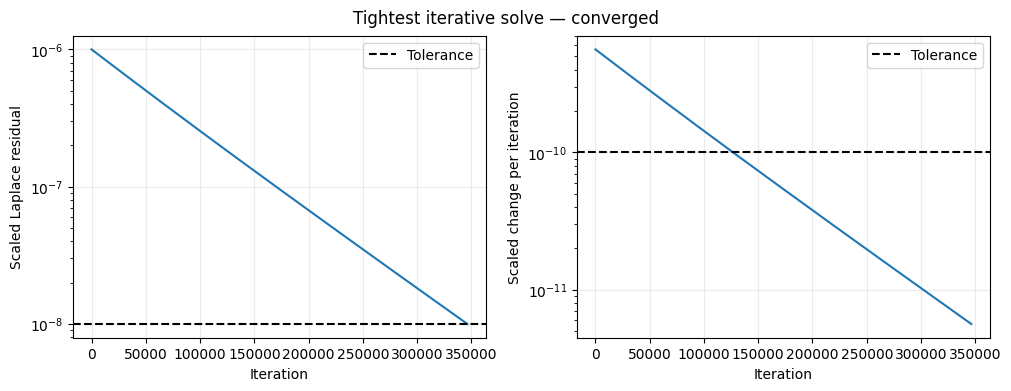

In [29]:
iterative_rows, iterative_runs = [], []
start = V_initial.copy()
cumulative_iterations = 0
previous = None
for tolerance in iterative_tolerances:
    print(f"Iterative study: residual tolerance {tolerance:g}")
    result = run_study_case(base_x, base_y, tolerance, start=start)
    cumulative_iterations += result["iterations"]
    row = result_row(f"tol={tolerance:g}", result)
    row["Cumulative iterations"] = cumulative_iterations
    row["Max change vs prior solve (V)"] = (
        pair_difference(previous, result, base_free) if previous is not None else np.nan
    )
    add_probe_values(row, result)
    iterative_rows.append(row)
    iterative_runs.append(result)
    start = result["V"].copy()
    previous = result

display_results(iterative_rows)
tight_result = iterative_runs[-1]
tight_tolerance = iterative_tolerances[-1]
fig, axes = plot_iteration_history(tight_result, "Tightest iterative solve")
plt.show()


### 7.2 Grid convergence

Bisect every interval of the base mesh, leaving the box and the conductor surfaces fixed. This refines the gaps, metal corners, and outer grid together. Recompute the stencil and stable time step for every mesh.

The comparison uses the same original vacuum sample nodes in every run; no interpolation is used to measure the differences. Interpolation is used only for the starting guess on a finer mesh.

For three consecutive refinement levels differing by one, a provisional observed order is

$$
p_{\mathrm{obs}}=
\log_2\left(\frac{D_{k-1}}{D_k}\right),
\qquad
D_k=\max_{\mathrm{base\ vacuum}}
|V_k-V_{k-1}|.
$$

Interpret this only when both differences are resolved above the iteration-error bounds and the sequence has reached an asymptotic regime. Corner singularities and grid grading can affect the observed order.

Refinement also decreases the explicit time step, so the finer solves may need a larger iteration cap. A capped run does not provide a grid-convergence result.

In [31]:
# 7.2 — Cheaper grid-convergence test
# Reuse the base mesh as the fine mesh; solve one coarser problem.

if not tight_result["converged"]:
    raise RuntimeError("Complete the base-mesh relaxation first.")

if not (
    np.array_equal(tight_result["x"], base_x)
    and np.array_equal(tight_result["y"], base_y)
):
    raise ValueError("tight_result must correspond to the base mesh.")


def coarsen_axis(axis, edges, probe_nodes):
    """Retain boundaries, metal edges, probes, and alternate other nodes."""
    protected = {0, len(axis) - 1}

    for coordinate in edges:
        index = int(np.argmin(np.abs(axis - coordinate)))
        if not np.isclose(axis[index], coordinate, rtol=0, atol=1e-11):
            raise ValueError("A conductor edge is missing from the base mesh.")
        protected.add(index)

    # Preserve the selected probe coordinates exactly.
    protected.update(int(index) for index in probe_nodes)

    # Coarsen separately between protected nodes.
    anchors = sorted(protected)
    keep = set(anchors)
    for left, right in zip(anchors[:-1], anchors[1:]):
        keep.update(range(left, right, 2))

    indices = np.array(sorted(keep), dtype=int)
    return axis[indices].copy(), indices


x_edges = [metal[key] for metal in study_conductors for key in ("xmin", "xmax")]
y_edges = [metal[key] for metal in study_conductors for key in ("ymin", "ymax")]

coarse_x, coarse_ix = coarsen_axis(
    base_x,
    x_edges,
    [i for j, i in probe_indices.values()],
)
coarse_y, coarse_iy = coarsen_axis(
    base_y,
    y_edges,
    [j for j, i in probe_indices.values()],
)

if len(coarse_x) == len(base_x) and len(coarse_y) == len(base_y):
    raise ValueError("No nodes could be removed from this mesh.")

print(f"Fine mesh, reused: {len(base_x)} × {len(base_y)} nodes")
print(f"Coarse mesh, new:  {len(coarse_x)} × {len(coarse_y)} nodes")

# Restrict the existing fine solution to shared nodes as the initial guess.
fine_on_coarse = tight_result["V"][np.ix_(coarse_iy, coarse_ix)]
coarse_result = run_study_case(
    coarse_x,
    coarse_y,
    tight_result["residual_tol"],
    start=fine_on_coarse.copy(),
)

shared_free = (
    coarse_result["boundary_data"]["free_mask"]
    & base_free[np.ix_(coarse_iy, coarse_ix)]
)
if not np.any(shared_free):
    raise ValueError("There are no shared vacuum nodes to compare.")

grid_difference_V = np.nan
if coarse_result["converged"]:
    grid_difference_V = float(
        np.max(np.abs(coarse_result["V"][shared_free] - fine_on_coarse[shared_free]))
    )

grid_pair_bound_V = (
    coarse_result["iteration_error_bound_V"] + tight_result["iteration_error_bound_V"]
)
grid_assessment = pair_assessment(coarse_result, tight_result, grid_difference_V)

# Keep both results for later inspection.
grid_runs = [coarse_result, tight_result]
grid_rows = []

for label, result in zip(
    ("Coarse mesh", "Fine mesh: reused base solution"),
    grid_runs,
):
    row = result_row(label, result)

    # All probe coordinates were explicitly retained.
    for name, (j, i) in probe_indices.items():
        ii = int(np.argmin(np.abs(result["x"] - base_x[i])))
        jj = int(np.argmin(np.abs(result["y"] - base_y[j])))
        row[f"{name} (V)"] = (
            float(result["V"][jj, ii]) if result["converged"] else np.nan
        )

    grid_rows.append(row)

grid_evidence_row = {
    "Test": "Grid",
    "Reference": "Coarser mesh, same geometry and box",
    "Comparison nodes": int(np.count_nonzero(shared_free)),
    "Max difference (V)": grid_difference_V,
    "Combined iteration bound (V)": grid_pair_bound_V,
    "Target (V)": comparison_target_V,
    "Assessment": grid_assessment,
}

display_results(grid_rows)
display_results([grid_evidence_row])

print(
    "This comparison samples shared vacuum nodes; "
    "it does not estimate a convergence order."
)


Fine mesh, reused: 177 × 189 nodes
Coarse mesh, new:  89 × 96 nodes
n=100,000: residual=1.567e-07, change=2.350e-10
n=159,900: residual=9.973e-09, change=1.496e-11


Run,Status,Nx,Ny,Iterations,Residual,Last change,Iteration error bound (V),Fixed error (V),Range violation (V),P0 (V),P1 (V),P2 (V)
Coarse mesh,converged,89,96,159900,9.9735e-09,1.4961e-11,1.9947e-06,0,0,-0.1353,0.14558,-0.27377
Fine mesh: reused base solution,converged,177,189,346300,9.9877e-09,5.6181e-12,1.9975e-06,0,0,-0.13515,0.14438,-0.27298


Test,Reference,Comparison nodes,Max difference (V),Combined iteration bound (V),Target (V),Assessment
Grid,"Coarser mesh, same geometry and box",7843,0.0098673,3.9922e-06,0.001,Difference exceeds target


This comparison samples shared vacuum nodes; it does not estimate a convergence order.


### 7.3 Domain convergence

Enlarge the box about its original center. Append geometrically growing intervals outside the old box, preserving every original node, all conductor coordinates, and all local spacings near the metals.

Compare consecutive solutions on the fixed near-conductor vacuum region. Former outer-boundary nodes become unknown vacuum nodes when the box grows; the masks are rebuilt accordingly.

The time-step limit is recalculated on each enlarged domain. The iterative error bound becomes more demanding as the box grows, so the table may request tighter stopping tolerances even if a residual tolerance has been met.

A small pairwise difference is evidence for stability within the sampled region and tested boxes. In two dimensions, logarithmic far-field behavior can make size dependence slow; this study does not establish a zero-at-infinity exterior solution for arbitrary prescribed voltages. Discretization of the new outer cells also remains part of the numerical error; refine the enlarged problem if needed.

In [33]:
domain_scales = (1.0, 1.5)


In [34]:
domain_rows, domain_runs = [], []
previous = None
xa, ya = base_x.copy(), base_y.copy()
center_x, center_y = (base_x[0] + base_x[-1]) / 2, (base_y[0] + base_y[-1]) / 2
half_x, half_y = (base_x[-1] - base_x[0]) / 2, (base_y[-1] - base_y[0]) / 2
previous_scale = 0.0
for scale in domain_scales:
    if scale < 1 or scale <= previous_scale:
        raise ValueError("Domain scales must increase and be at least one.")
    previous_scale = scale
    xa = extend_axis_preserving_nodes(
        xa,
        center_x - scale * half_x,
        center_x + scale * half_x,
        ratio=growth_ratio,
    )
    ya = extend_axis_preserving_nodes(
        ya,
        center_y - scale * half_y,
        center_y + scale * half_y,
        ratio=growth_ratio,
    )
    if scale == 1.0:
        result = tight_result
    else:
        seed_result = previous if previous is not None else tight_result
        start = interpolated_start(seed_result, xa, ya)
        print(f"Domain study: box scale {scale:g}, {len(xa)} x {len(ya)} nodes")
        result = run_study_case(xa, ya, tight_tolerance, start=start)

    difference = (
        pair_difference(previous, result, near_region)
        if previous is not None
        else np.nan
    )
    assessment = (
        pair_assessment(previous, result, difference)
        if previous is not None
        else "Reference box"
    )
    row = result_row(f"box scale {scale:g}", result)
    row.update({"Near-region difference (V)": difference, "Assessment": assessment})
    add_probe_values(row, result)
    domain_rows.append(row)
    domain_runs.append(result)
    previous = result

display_results(domain_rows)


Domain study: box scale 1.5, 185 x 197 nodes
n=100,000: residual=3.072e-04, change=1.728e-07
n=200,000: residual=1.452e-04, change=8.169e-08
n=300,000: residual=7.139e-05, change=4.016e-08
n=400,000: residual=3.560e-05, change=2.002e-08
n=500,000: residual=1.805e-05, change=1.016e-08
n=600,000: residual=9.323e-06, change=5.244e-09
n=700,000: residual=4.903e-06, change=2.758e-09
n=800,000: residual=2.626e-06, change=1.477e-09
n=900,000: residual=1.430e-06, change=8.045e-10
n=1,000,000: residual=7.914e-07, change=4.451e-10
n=1,100,000: residual=4.441e-07, change=2.498e-10
n=1,200,000: residual=2.530e-07, change=1.423e-10
n=1,300,000: residual=1.456e-07, change=8.193e-11
n=1,400,000: residual=8.450e-08, change=4.753e-11
n=1,500,000: residual=4.935e-08, change=2.776e-11
n=1,600,000: residual=2.900e-08, change=1.631e-11
n=1,700,000: residual=1.709e-08, change=9.614e-12
n=1,800,000: residual=1.010e-08, change=5.682e-12
n=1,802,000: residual=9.995e-09, change=5.622e-12


Run,Status,Nx,Ny,Iterations,Residual,Last change,Iteration error bound (V),Fixed error (V),Range violation (V),Near-region difference (V),Assessment,P0 (V),P1 (V),P2 (V)
box scale 1,converged,177,189,346300,9.9877e-09,5.6181e-12,1.9975e-06,0,0,—,Reference box,-0.13515,0.14438,-0.27298
box scale 1.5,converged,185,197,1802000,9.9951e-09,5.6223e-12,4.4978e-06,0,0,0.0081052,Difference exceeds target,-0.13559,0.14412,-0.27434


### 7.4 Time-step independence

Repeat the solve on the base mesh with different stable values of the time-step safety factor, starting from the same zero-vacuum initial guess each time. Both runs must satisfy the same residual and change tolerances.

The stationary discrete solution should agree within the remaining iteration errors. The artificial time step changes the route and speed of relaxation; at full convergence it does not change the stationary finite-difference equations.

This check is separate from mesh and box convergence and can be computationally expensive with the explicit method.

In [35]:
time_step_rows, time_step_runs = [], []
previous = None
for factor in time_step_factors:
    print(f"Time-step study: safety factor {factor:g}")
    result = run_study_case(
        base_x,
        base_y,
        tight_tolerance,
        start=V_initial.copy(),
        safety=factor,
    )
    difference = (
        pair_difference(previous, result, base_free) if previous is not None else np.nan
    )
    row = result_row(f"safety={factor:g}", result)
    row.update(
        {
            "dtau": result["dtau"],
            "Difference vs prior (V)": difference,
            "Assessment": (
                pair_assessment(previous, result, difference)
                if previous is not None
                else "Reference time step"
            ),
        }
    )
    add_probe_values(row, result)
    time_step_rows.append(row)
    time_step_runs.append(result)
    previous = result

display_results(time_step_rows)


Time-step study: safety factor 0.45
n=100,000: residual=2.690e-03, change=7.564e-07
n=200,000: residual=9.316e-04, change=2.620e-07
n=300,000: residual=3.885e-04, change=1.093e-07
n=400,000: residual=1.687e-04, change=4.744e-08
n=500,000: residual=7.496e-05, change=2.108e-08
n=600,000: residual=3.399e-05, change=9.559e-09
n=700,000: residual=1.571e-05, change=4.418e-09
n=800,000: residual=7.397e-06, change=2.081e-09
n=900,000: residual=3.548e-06, change=9.978e-10
n=1,000,000: residual=1.733e-06, change=4.874e-10
n=1,100,000: residual=8.613e-07, change=2.422e-10
n=1,200,000: residual=4.334e-07, change=1.219e-10
n=1,300,000: residual=2.203e-07, change=6.196e-11
n=1,400,000: residual=1.131e-07, change=3.181e-11
n=1,500,000: residual=5.847e-08, change=1.645e-11
n=1,600,000: residual=3.038e-08, change=8.544e-12
n=1,700,000: residual=1.584e-08, change=4.456e-12
n=1,771,100: residual=9.995e-09, change=2.811e-12
Time-step study: safety factor 0.9
n=100,000: residual=9.315e-04, change=5.240e-07

Run,Status,Nx,Ny,Iterations,Residual,Last change,Iteration error bound (V),Fixed error (V),Range violation (V),dtau,Difference vs prior (V),Assessment,P0 (V),P1 (V),P2 (V)
safety=0.45,converged,177,189,1771100,9.9945e-09,2.811e-12,1.9989e-06,0,0,0.00028125,—,Reference time step,-0.13515,0.14438,-0.27298
safety=0.9,converged,177,189,885600,9.9877e-09,5.6181e-12,1.9975e-06,0,0,0.0005625,2.9709e-10,Pair meets chosen target,-0.13515,0.14438,-0.27298


ValueError: x and y must have same first dimension, but have shapes (3,) and (2,)

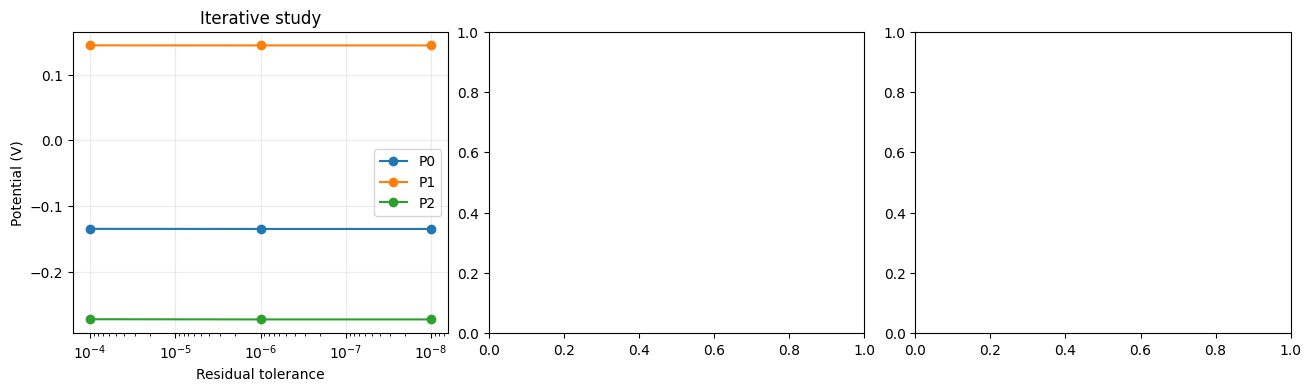

In [36]:
def plot_study_probes(rows_by_study, parameters, xlabel_by_study):
    """Plot only iteratively converged probe values for each study."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
    for ax, name in zip(axes, ("Iterative", "Grid", "Domain")):
        rows = rows_by_study[name]
        horizontal = np.asarray(parameters[name])
        for probe in probe_indices:
            values = np.asarray([row[f"{probe} (V)"] for row in rows], dtype=float)
            ax.plot(horizontal, values, "o-", label=probe)
        if name == "Iterative":
            ax.set_xscale("log")
            ax.invert_xaxis()
        ax.set_xlabel(xlabel_by_study[name])
        ax.set_ylabel("Potential (V)")
        ax.set_title(name + " study")
        ax.grid(alpha=0.25)
        ax.legend()
    return fig, axes


fig, axes = plot_study_probes(
    {"Iterative": iterative_rows, "Grid": grid_rows, "Domain": domain_rows},
    {
        "Iterative": iterative_tolerances,
        "Grid": mesh_refinements,
        "Domain": domain_scales,
    },
    {
        "Iterative": "Residual tolerance",
        "Grid": "Refinement level",
        "Domain": "Box scale",
    },
)
plt.show()


### Read the results before choosing a final configuration

- Check the analytic validation errors and boundary preservation first.
- Every solution used in a comparison must have status **converged**.
- Compare the reported iteration-error bounds with the field differences. Tighten the solver if iteration error could hide the effect being tested.
- A pair meeting the selected voltage target is one piece of evidence. Inspect the trend and extend the sequence if the differences are irregular or near the target.
- For the final calculation, combine a sufficiently fine mesh with a sufficiently large box, then recheck the relevant sensitivities. The largest-box and finest-mesh runs above are separate studies and are not automatically one validated final configuration.
- Keep the chosen values of mesh spacing, grid grading, box size, time step, tolerances, iteration cap, and observed diagnostics in the report.

No numerical conclusions have been filled in: all cells are delivered unexecuted.

## Step 8 — Present the converged potential

Continue here by selecting the configuration justified by the tests and plotting the potential map and equipotential contours.

## Step 8 — Present the potential and convergence evidence

**Append these cells after step 7 in the main notebook.** They use the results and functions created by steps 1–7 and have not been executed.

This section presents `tight_result`: the base-grid, base-box solution at the tightest iterative tolerance. It compares that **same plotted solution** directly with the finest tested mesh and largest tested box. A solver stopping flag alone does not establish mesh or domain convergence.

If the comparisons fail the chosen target, the plots remain useful as an iteratively converged finite-box result. Revise the base mesh or box using the study results and repeat the relevant checks before presenting it as your final numerical configuration.

The map shows $V(X,Y)$ in volts; the contour panel shows curves satisfying

$$
V(X,Y)=V_c,\qquad X=x/a,\quad Y=y/a.
$$

The contour calculation excludes the metal interiors, and their exact rectangular outlines are drawn over the plot.

In [ ]:
# This section reuses existing results; it does not launch additional solves.
required_names = (
    "np",
    "plt",
    "Rectangle",
    "tight_result",
    "iterative_runs",
    "grid_runs",
    "domain_runs",
    "base_x",
    "base_y",
    "base_free",
    "near_region",
    "study_conductors",
    "probe_indices",
    "comparison_target_V",
    "iteration_budget_fraction",
    "display_results",
    "result_row",
    "add_probe_values",
    "pair_difference",
    "pair_assessment",
    "plot_iteration_history",
)
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Append this section to the main notebook and execute steps 1–7 first. "
        "Missing objects: " + ", ".join(missing_names)
    )

presented_result = tight_result
if not presented_result["converged"]:
    raise RuntimeError(
        "The selected result reached the iteration cap. Increase the cap "
        "or resolve the stopping criteria before presenting a converged potential."
    )
if not np.array_equal(presented_result["x"], base_x) or not np.array_equal(
    presented_result["y"], base_y
):
    raise ValueError("These comparisons require tight_result on the base grid and box.")


def presentation_comparison(test, reference, sampling_mask, description, varied):
    row = {
        "Test": test,
        "Reference": description,
        "Comparison nodes": int(np.count_nonzero(sampling_mask)),
        "Max difference (V)": np.nan,
        "Combined iteration bound (V)": np.nan,
        "Target (V)": comparison_target_V,
        "Assessment": "Not assessed: at least two distinct settings are required",
    }
    if reference is None or not varied:
        return row
    difference = pair_difference(presented_result, reference, sampling_mask)
    row["Max difference (V)"] = difference
    row["Combined iteration bound (V)"] = (
        presented_result["iteration_error_bound_V"]
        + reference["iteration_error_bound_V"]
    )
    row["Assessment"] = pair_assessment(presented_result, reference, difference)
    return row


iteration_reference = iterative_runs[-2] if len(iterative_runs) >= 2 else None
mesh_reference = grid_runs[-1] if grid_runs else None
box_reference = domain_runs[-1] if domain_runs else None
mesh_varied = mesh_reference is not None and (
    len(mesh_reference["x"]) > len(base_x) or len(mesh_reference["y"]) > len(base_y)
)
box_varied = box_reference is not None and (
    box_reference["x"][0] < base_x[0]
    or box_reference["x"][-1] > base_x[-1]
    or box_reference["y"][0] < base_y[0]
    or box_reference["y"][-1] > base_y[-1]
)

evidence_rows = [
    presentation_comparison(
        "Iterative",
        iteration_reference,
        base_free,
        "Previous stopping tolerance, same mesh and box",
        iteration_reference is not None
        and (
            iteration_reference["residual_tol"] != presented_result["residual_tol"]
            or iteration_reference["change_tol"] != presented_result["change_tol"]
        ),
    ),
    grid_evidence_row.copy(),
    presentation_comparison(
        "Domain",
        box_reference,
        near_region,
        "Largest tested box, unchanged base-grid nodes",
        box_varied,
    ),
]

# Include the independent time-step test if that optional study was executed.
if "time_step_runs" in globals():
    alternatives = [
        result
        for result in time_step_runs
        if not np.isclose(result["dtau"], presented_result["dtau"], rtol=1e-10, atol=0)
    ]
    if alternatives:
        evidence_rows.append(
            presentation_comparison(
                "Time step",
                alternatives[0],
                base_free,
                "Different stable time step, same mesh and box",
                True,
            )
        )

fixed_check_tol = 1e-12 * presented_result["voltage_scale"]
boundary_checks_pass = (
    presented_result["fixed_error_V"] <= fixed_check_tol
    and presented_result["maximum_principle_violation_V"] <= fixed_check_tol
)
required_evidence_pass = boundary_checks_pass and all(
    row["Assessment"] == "Pair meets chosen target" for row in evidence_rows
)

presentation_status = (
    f"Selected comparisons meet {comparison_target_V:g} V target"
    if required_evidence_pass
)

summary_row = result_row("Presented base-grid/base-box solution", presented_result)
summary_row.update(
    {
        "x/a interval": f"[{base_x[0]:g}, {base_x[-1]:g}]",
        "y/a interval": f"[{base_y[0]:g}, {base_y[-1]:g}]",
        "dx/a min": float(np.diff(base_x).min()),
        "dx/a max": float(np.diff(base_x).max()),
        "dy/a min": float(np.diff(base_y).min()),
        "dy/a max": float(np.diff(base_y).max()),
        "dtau": presented_result["dtau"],
        "Residual tolerance": presented_result["residual_tol"],
        "Change tolerance": presented_result["change_tol"],
    }
)
add_probe_values(summary_row, presented_result)
print(presentation_status)
display_results([summary_row])
display_results(evidence_rows)


Iteratively converged; numerical sensitivity checks remain


Run,Status,Nx,Ny,Iterations,Residual,Last change,Iteration error bound (V),Fixed error (V),Range violation (V),x/a interval,y/a interval,dx/a min,dx/a max,dy/a min,dy/a max,dtau,Residual tolerance,Change tolerance,P0 (V),P1 (V),P2 (V)
Presented base-grid/base-box solution,converged,177,189,346300,9.9877e-09,5.6181e-12,1.9975e-06,0,0,"[-20, 20]","[-20, 20]",0.05,2.3291,0.05,2.2626,0.0005625,1e-08,1e-10,-0.13515,0.14438,-0.27298


Test,Reference,Comparison nodes,Max difference (V),Combined iteration bound (V),Target (V),Assessment
Iterative,"Previous stopping tolerance, same mesh and box",31571,4.0849e-05,0.00020183,0.001,Tighten solver tolerances
Grid,"Coarser mesh, same geometry and box",7843,0.0098673,3.9922e-06,0.001,Difference exceeds target
Domain,"Largest tested box, unchanged base-grid nodes",14939,0.0081052,6.4953e-06,0.001,Difference exceeds target
Time step,"Different stable time step, same mesh and box",31571,2.9709e-10,3.9964e-06,0.001,Pair meets chosen target


### Potential map and equipotential contours

The left panel covers the full computational box. The right panel enlarges the conductor region, uses the same voltage scale, and overlays labeled equipotential contours. The marked probe points match the numerical comparisons.

The plot uses the actual nonuniform coordinates. A masked potential is used only to keep contour lines out of the conductors; the numerical solution array remains intact.

The status in the figure reports the outcome of the selected comparisons. Passing these finite-grid and finite-box comparisons does not by itself prove compatibility with $V(\infty)=0$ in the two-dimensional exterior problem.

In [2]:
def plot_presented_potential(result, conductors, status, zoom_padding=1.0):
    from matplotlib.colors import Normalize, TwoSlopeNorm

    xf, yf, potential = result["x"], result["y"], result["V"]
    bc = result["boundary_data"]
    metal_mask = np.zeros(potential.shape, dtype=bool)
    for mask in bc["conductor_masks"].values():
        metal_mask |= mask
    vacuum_potential = np.ma.array(potential, mask=metal_mask, copy=False)

    vmin, vmax = float(potential.min()), float(potential.max())
    if vmin < 0 < vmax:
        bound = max(abs(vmin), abs(vmax))
        norm = TwoSlopeNorm(vmin=-bound, vcenter=0.0, vmax=bound)
        cmap = "RdBu_r"
    else:
        padding = 1e-6 * max(1.0, abs(vmin)) if vmin == vmax else 0.0
        norm = Normalize(vmin=vmin - padding, vmax=vmax + padding)
        cmap = "viridis"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
    full, zoom = axes
    image = full.pcolormesh(
        xf,
        yf,
        potential,
        shading="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )
    zoom.pcolormesh(
        xf,
        yf,
        potential,
        shading="nearest",
        cmap=cmap,
        norm=norm,
        alpha=0.30,
        rasterized=True,
    )
    zoom.set_xlim(
        min(m["xmin"] for m in conductors) - zoom_padding,
        max(m["xmax"] for m in conductors) + zoom_padding,
    )
    zoom.set_ylim(
        min(m["ymin"] for m in conductors) - zoom_padding,
        max(m["ymax"] for m in conductors) + zoom_padding,
    )

    vacuum_values = vacuum_potential.compressed()
    vacuum_span = float(np.ptp(vacuum_values))
    if vacuum_span > 1e-12 * result["voltage_scale"]:
        levels = np.linspace(vmin, vmax, 15)[1:-1]
        levels = levels[
            (levels > float(vacuum_values.min()))
            & (levels < float(vacuum_values.max()))
        ]
        if len(levels):
            contours = zoom.contour(
                xf,
                yf,
                vacuum_potential,
                levels=levels,
                colors="#202020",
                linewidths=0.85,
                corner_mask=False,
            )
            zoom.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
    else:
        zoom.text(
            0.5,
            0.97,
            "Vacuum potential is constant to plotting precision",
            transform=zoom.transAxes,
            ha="center",
            va="top",
            fontsize=9,
        )

    for ax in axes:
        for metal in conductors:
            ax.add_patch(
                Rectangle(
                    (metal["xmin"], metal["ymin"]),
                    metal["xmax"] - metal["xmin"],
                    metal["ymax"] - metal["ymin"],
                    facecolor="white" if ax is zoom else "none",
                    edgecolor="black",
                    linewidth=1.1,
                    zorder=5,
                )
            )
            if ax is zoom:
                ax.text(
                    (metal["xmin"] + metal["xmax"]) / 2,
                    (metal["ymin"] + metal["ymax"]) / 2,
                    str(metal["number"]),
                    ha="center",
                    va="center",
                    fontsize=10,
                    zorder=6,
                )
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(r"$x/a$")
        ax.set_ylabel(r"$y/a$")

    for name, (j, i) in probe_indices.items():
        xp, yp = base_x[i], base_y[j]
        zoom.plot(xp, yp, "kx", markersize=5, zorder=7)
        zoom.annotate(
            name,
            (xp, yp),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8,
            zorder=7,
        )

    full.set_xlim(xf[0], xf[-1])
    full.set_ylim(yf[0], yf[-1])
    full.set_title("Electrostatic potential: full box")
    zoom.set_title("Equipotential contours near the conductors")
    fig.colorbar(image, ax=list(axes), label="Potential (V)", shrink=0.88)
    fig.suptitle(status, fontsize=11)
    return fig, axes


potential_figure, potential_axes = plot_presented_potential(
    presented_result, study_conductors, presentation_status
)
plt.show()


NameError: name 'presented_result' is not defined

### Selected numerical evidence

The next figure shows residual and update convergence during the final tolerance stage. Because the tolerance study uses warm starts, its iteration axis counts iterations in that stage.

The comparison plot shows the differences listed in the table. Gray marks indicate the combined bounds on remaining iteration error. An unresolved comparison is labeled instead of being plotted as zero.

The grid and domain quantities refer to their stated sampling regions: all base-grid vacuum nodes for the grid test and the fixed near-conductor region for the domain test. Probe values alone do not replace these broader comparisons.

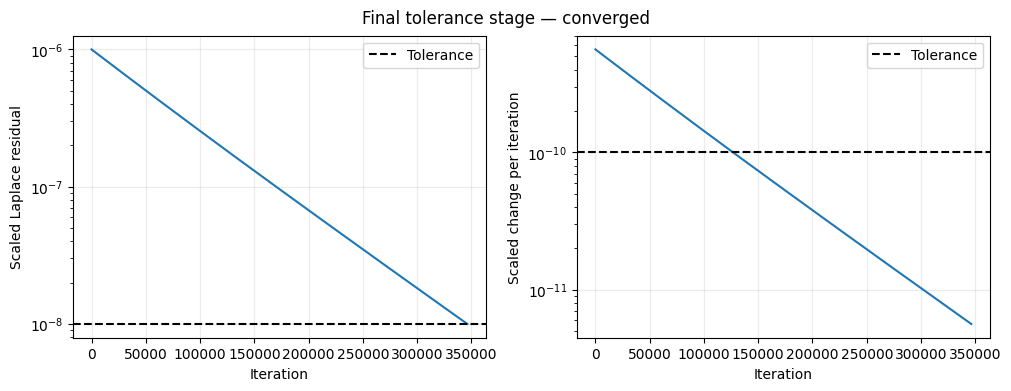

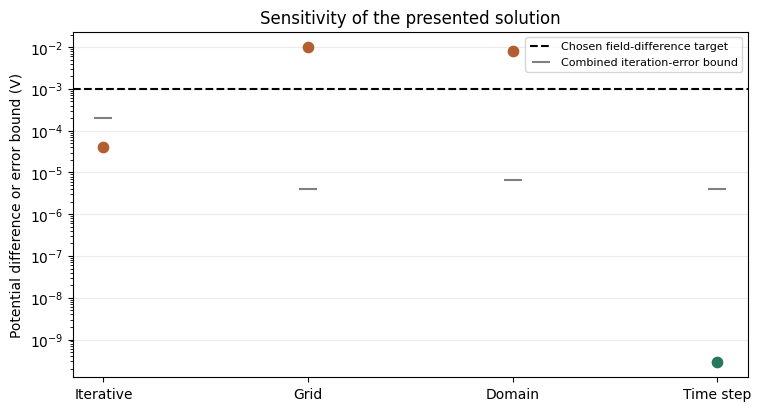

In [39]:
iteration_figure, iteration_axes = plot_iteration_history(
    presented_result, "Final tolerance stage"
)
plt.show()

comparison_figure, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
plot_floor = max(comparison_target_V * 1e-8, np.finfo(float).tiny)
for index, row in enumerate(evidence_rows):
    difference = row["Max difference (V)"]
    bound = row["Combined iteration bound (V)"]
    passed = row["Assessment"] == "Pair meets chosen target"
    if np.isfinite(difference):
        shown_difference = max(difference, plot_floor)
        ax.scatter(
            index,
            shown_difference,
            color="#27785a" if passed else "#b35e30",
            s=55,
            zorder=4,
        )
        if difference == 0:
            ax.annotate(
                "0",
                (index, shown_difference),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )
        if np.isfinite(bound):
            ax.scatter(
                index, max(bound, plot_floor), color="0.5", marker="_", s=170, zorder=3
            )
    else:
        ax.text(
            index,
            0.04,
            "Unresolved",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=9,
        )

ax.axhline(
    comparison_target_V,
    color="black",
    linestyle="--",
    label="Chosen field-difference target",
)
ax.scatter(
    [], [], color="0.5", marker="_", s=170, label="Combined iteration-error bound"
)
ax.set_yscale("log")
ax.set_xticks(range(len(evidence_rows)))
ax.set_xticklabels([row["Test"] for row in evidence_rows])
ax.set_ylabel("Potential difference or error bound (V)")
ax.set_title("Sensitivity of the presented solution")
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8)
plt.show()

# Optional exports when YOU execute the notebook.
save_figures = False
if save_figures:
    potential_figure.savefig(
        "HW4_potential_and_contours.png", dpi=300, bbox_inches="tight"
    )
    iteration_figure.savefig("HW4_iteration_evidence.png", dpi=300, bbox_inches="tight")
    comparison_figure.savefig(
        "HW4_numerical_comparisons.png", dpi=300, bbox_inches="tight"
    )


### Statements supported by the output

Use the reported values rather than assuming that any check has passed:

- The reported residual and final update show whether the selected finite-difference problem has reached its stopping thresholds.
- Fixed-value error and range violation check boundary preservation and the discrete maximum principle.
- The direct differences from the refined-grid and enlarged-box solutions quantify sensitivity of the **plotted** solution on the stated sample nodes.
- Differences below the selected target are useful only when the remaining iteration error is sufficiently smaller, as checked in the table.
- If a check remains unresolved or exceeds the target, report that limitation and improve the corresponding numerical parameter before making a stronger convergence claim.

The analytic-validation results in step 6 should accompany these checks. All figures and numerical values in this section are generated only when you run its cells.